#**Problem Statement**
Despite high Aadhaar coverage, enrolment, demographic changes, and biometric changes patterns show regional and age-wise disparities.
This analysis aims to identify enrolment gaps, high-load regions, and temporal trends
using exploratory data analysis and statistical techniques.

## **Analytical Approach**
We use descriptive statistics, univariate, bivariate, temporal analysis and Hypothesis Testing on
aggregated Aadhaar enrolment data.


#1. Problem Understanding
##Objective

The objective of this project is to analyze Aadhaar enrolment patterns (2025) to:

Identify regional disparities

Detect age-wise enrolment gaps

Find high-load regions

Study temporal enrolment trends

## Research Motivation

Even though Aadhaar coverage in India is high, there may be:

Uneven enrolment across states

Age-group disparities

District-level imbalances

Data inconsistencies affecting policy decisions

Hence, Exploratory Data Analysis (EDA) and statistical techniques are applied.

# **Mounting Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Purpose

To access large CSV datasets stored in Google Drive.

Necessary due to dataset size.

##Finding

Drive was already mounted → No environment issue detected.

# **Importing Required Libraries**

In [ ]:
!pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy.stats import chi2_contingency, kruskal

##Purpose

pandas → Data manipulation

numpy → Numerical operations

matplotlib, seaborn → Statistical visualization

plotly → Interactive visualization

##Observation

The chosen libraries are sufficient for:

Descriptive statistics

Univariate & bivariate analysis

Time-series visualization

# Dataset Description
We have three interrelated different datasets of Aadhar i.e. Aadhaar Enrolment, Demographic, and Biometric Dataset for year 2025 and contains columns
date, state, district, PIN code, and age groups (0–5, 5–17, and 18+).

## Methodology
1. Data loading and integration
2. Data type standardisation
3. Missing value and duplicate handling
4. Feature engineering (total enrolment, ratios)
5. Exploratory Data Analysis
6. Statistical outlier identification


# **Data Loading and Integration**

In [ ]:
enrol_path = "/content/drive/MyDrive/Aadhar/api_data_aadhar_enrolment/"
demo_path = "/content/drive/MyDrive/Aadhar/api_data_aadhar_demographic/"
bio_path = "/content/drive/MyDrive/Aadhar/api_data_aadhar_biometric/"

In [ ]:
# Enrolment Datasets
enrol_df1 = pd.read_csv(enrol_path + "api_data_aadhar_enrolment_0_500000.csv")
enrol_df2 = pd.read_csv(enrol_path + "api_data_aadhar_enrolment_500000_1000000.csv")
enrol_df3 = pd.read_csv(enrol_path + "api_data_aadhar_enrolment_1000000_1006029.csv")

# Demographic Datasets
demo_df1 = pd.read_csv(demo_path + "api_data_aadhar_demographic_0_500000.csv")
demo_df2 = pd.read_csv(demo_path + "api_data_aadhar_demographic_500000_1000000.csv")
demo_df3 = pd.read_csv(demo_path + "api_data_aadhar_demographic_1000000_1500000.csv")
demo_df4 = pd.read_csv(demo_path + "api_data_aadhar_demographic_1500000_2000000.csv")
demo_df5 = pd.read_csv(demo_path + "api_data_aadhar_demographic_2000000_2071700.csv")

# Biometric Datasets
bio_df1 = pd.read_csv(bio_path + "api_data_aadhar_biometric_0_500000.csv")
bio_df2 = pd.read_csv(bio_path + "api_data_aadhar_biometric_500000_1000000.csv")
bio_df3 = pd.read_csv(bio_path + "api_data_aadhar_biometric_1000000_1500000.csv")
bio_df4 = pd.read_csv(bio_path + "api_data_aadhar_biometric_1500000_1861108.csv")

#Dataset Description

Three datasets were used:

Enrolment Dataset

Demographic Dataset

Biometric Dataset

##Each dataset contains:

Date

State

District

PIN code

Age group columns

## Finding

The datasets are interrelated but stored separately.
This requires:

Schema verification

Proper merging

Standardization

# **Verify Column Consistency**

In [ ]:
# Check columns name are consistent
def verify_column_consistency(df1, df2):
    consistent = df1.columns.equals(df2.columns)

    if consistent:
        print("Columns of are equal")
    else:
        print("Columns are not equal")

    return consistent

In [ ]:
# Checking column consistency for Enrolment datasets
print(verify_column_consistency(enrol_df1, enrol_df2))
print(verify_column_consistency(enrol_df1, enrol_df3))

Columns of are equal
True
Columns of are equal
True


Enrolment Dataset's columns are consistent

In [ ]:
# Checking column consistency for Demographics datasets
print(verify_column_consistency(demo_df1, demo_df2))
print(verify_column_consistency(demo_df1, demo_df3))
print(verify_column_consistency(demo_df1, demo_df4))
print(verify_column_consistency(demo_df1, demo_df5))

Columns of are equal
True
Columns of are equal
True
Columns of are equal
True
Columns of are equal
True


Demographic Dataset's columns are consistent

In [ ]:
# Checking column consistency for Biometric datasets
print(verify_column_consistency(bio_df1, bio_df2))
print(verify_column_consistency(bio_df1, bio_df3))
print(verify_column_consistency(bio_df1, bio_df4))

Columns of are equal
True
Columns of are equal
True
Columns of are equal
True


Biometric Dataset's columns are consistent

#Purpose

To ensure:

All CSV chunks of a dataset have identical columns

Safe concatenation

##Findings

✔ Enrolment dataset → consistent
✔ Demographic dataset → consistent
✔ Biometric dataset → consistent

##This confirms:

No schema mismatch

No structural corruption

# **Merge All Datasets**


In [ ]:
# All enrolment data as enrol_df
enrol_df = pd.concat([enrol_df1, enrol_df2, enrol_df3], ignore_index=True)

# All enrolment data as demo_df
demo_df= pd.concat([demo_df1, demo_df2, demo_df3, demo_df4, demo_df5], ignore_index=True)

# All enrolment data as bio_df
bio_df = pd.concat([bio_df1, bio_df2, bio_df3, bio_df4], ignore_index=True)

## **Shape Checker Function**

In [ ]:
def shape_checker(df, name):
    print(f"Shape of {name} after merger: {df.shape}")
    print()

In [ ]:
shape_checker(enrol_df, "enrol_df")
shape_checker(demo_df, "demo_df")
shape_checker(bio_df, "bio_df")

Shape of enrol_df after merger: (1006029, 7)

Shape of demo_df after merger: (2071700, 6)

Shape of bio_df after merger: (1861108, 6)



##Findings

Large-scale dataset (~5 million total rows across datasets)

No row loss during concatenation

Ready for integrated analysis

## **Head Checker Function**

In [ ]:
def head_checker(df, name):
  print(f"Head of {name}:")
  display(df.head())
  print("\n")

In [ ]:
head_checker(enrol_df, "enrol_df")
head_checker(demo_df, "demo_df")
head_checker(bio_df, "bio_df")

Head of enrol_df:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21




Head of demo_df:


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785




Head of bio_df:


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


## **Tail Checker Function**

In [ ]:
def tail_checker(df, name):
  print(f"Tail of {name}:")
  display(df.tail())
  print("\n")

In [ ]:
tail_checker(enrol_df, "enrol_df")
tail_checker(demo_df, "demo_df")
tail_checker(bio_df, "bio_df")

Tail of enrol_df:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
1006024,31-12-2025,West Bengal,West Midnapore,721149,2,0,0
1006025,31-12-2025,West Bengal,West Midnapore,721150,2,2,0
1006026,31-12-2025,West Bengal,West Midnapore,721305,0,1,0
1006027,31-12-2025,West Bengal,West Midnapore,721504,1,0,0
1006028,31-12-2025,West Bengal,West Midnapore,721517,2,1,0




Tail of demo_df:


,date,state,district,pincode,demo_age_5_17,demo_age_17_
2071695,29-12-2025,West Bengal,West Midnapore,721212,0,12
2071696,29-12-2025,West Bengal,West Midnapore,721420,0,1
2071697,29-12-2025,West Bengal,West Midnapore,721424,0,5
2071698,29-12-2025,West Bengal,West Midnapore,721426,0,3
2071699,29-12-2025,West Bengal,hooghly,712701,0,1




Tail of bio_df:


,date,state,district,pincode,bio_age_5_17,bio_age_17_
1861103,29-12-2025,West Bengal,Uttar Dinajpur,733201,4,9
1861104,29-12-2025,West Bengal,Uttar Dinajpur,733213,0,1
1861105,29-12-2025,West Bengal,West Midnapore,721304,0,3
1861106,29-12-2025,West Bengal,West Midnapore,721451,2,0
1861107,29-12-2025,West Bengal,West Midnapore,721457,0,1


# **Understand the Dataset Structure**

In [ ]:
shape_checker(enrol_df, "enrol_df")
shape_checker(demo_df, "demo_df")
shape_checker(bio_df, "bio_df")

Shape of enrol_df after merger: (1006029, 7)

Shape of demo_df after merger: (2071700, 6)

Shape of bio_df after merger: (1861108, 6)



## **Column Checking Function**

In [ ]:
def column_checker(df, name):
  print(f"Columns of {name}:")
  display(df.columns.tolist())
  print("\n")

In [ ]:
column_checker(enrol_df, "enrol_df")
column_checker(demo_df, "demo_df")
column_checker(bio_df, "bio_df")

Columns of enrol_df:


['date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater']



Columns of demo_df:


['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']



Columns of bio_df:


['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']

## **Index Checking Function**

In [ ]:
def index_checker(df, name):
  print(f"Index of {name}:")
  display(df.index)
  print("\n")

In [ ]:
index_checker(enrol_df, "enrol_df")
index_checker(demo_df, "demo_df")
index_checker(bio_df, "bio_df")

Index of enrol_df:


RangeIndex(start=0, stop=1006029, step=1)



Index of demo_df:


RangeIndex(start=0, stop=2071700, step=1)



Index of bio_df:


RangeIndex(start=0, stop=1861108, step=1)

#Purpose

To understand:

Dataset dimensions

Column names

Index structure

Sample data patterns

## Findings

Index is continuous and properly assigned

Columns match dataset description

Data appears logically structured

##This step confirms:
 Data ingestion was successful.

#Column Renaming

In [ ]:
#renaming columns
demo_df = demo_df.rename(columns={'demo_age_5_17': 'age_5_17',
                                  'demo_age_17_': 'age_18_greater'
                                 })

bio_df = bio_df.rename(columns={'bio_age_5_17': 'age_5_17',
                                'bio_age_17_': 'age_18_greater'
                                })

In [ ]:
column_checker(enrol_df, "enrol_df")
column_checker(demo_df, "demo_df")
column_checker(bio_df, "bio_df")

Columns of enrol_df:


['date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater']



Columns of demo_df:


['date', 'state', 'district', 'pincode', 'age_5_17', 'age_18_greater']



Columns of bio_df:


['date', 'state', 'district', 'pincode', 'age_5_17', 'age_18_greater']

#Purpose

Improve readability

Remove ambiguous column names

Prepare for feature engineering

## Finding

Column naming was inconsistent originally.
Renaming improves:

Semantic clarity

Maintainability of code

Interpretation during reporting

# **Info Checking Function**

In [ ]:
def info_checker(df, name):
  print(f"Info of {name}:")
  print()
  display(df.info())
  print("\n")

In [ ]:
info_checker(enrol_df,"enrol_df")

Info of enrol_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


None

In [ ]:
info_checker(demo_df,"demo_df")

Info of demo_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071700 entries, 0 to 2071699
Data columns (total 6 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   date            object
 1   state           object
 2   district        object
 3   pincode         int64 
 4   age_5_17        int64 
 5   age_18_greater  int64 
dtypes: int64(3), object(3)
memory usage: 94.8+ MB


None

In [ ]:
info_checker(bio_df,"bio_df")

Info of bio_df:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   date            object
 1   state           object
 2   district        object
 3   pincode         int64 
 4   age_5_17        int64 
 5   age_18_greater  int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


None

# **Data Type Checker**

In [ ]:
def dtypes_checker(df, name):
  print(f"Data types of {name}:")
  display(df.dtypes)
  print("\n")

In [ ]:
dtypes_checker(enrol_df,"enrol_df")
dtypes_checker(demo_df,"demo_df")
dtypes_checker(bio_df,"bio_df")

Data types of enrol_df:


,0
date,object
state,object
district,object
pincode,int64
age_0_5,int64
age_5_17,int64
age_18_greater,int64




Data types of demo_df:


,0
date,object
state,object
district,object
pincode,int64
age_5_17,int64
age_18_greater,int64




Data types of bio_df:


,0
date,object
state,object
district,object
pincode,int64
age_5_17,int64
age_18_greater,int64


#Purpose

To verify:

Numeric vs object columns

Date format correctness

Memory usage

##Findings

Date column still in object format (needs conversion)

Age columns are numeric

State and district are categorical (object type)

##This step confirms:
Data types need minor transformation for time-series analysis

# **Numerical Column Description Checking Function**

In [ ]:
def describe_checker(df, name):
  print(f"Description of {name}:")
  display(df.describe(include= 'number').iloc[:,1:].round(2))
  print("\n")

In [ ]:
describe_checker(enrol_df,"enrol_df")
describe_checker(demo_df,"demo_df")
describe_checker(bio_df,"bio_df")

Description of enrol_df:


,age_0_5,age_5_17,age_18_greater
count,1006029.00,1006029.00,1006029.00
mean,3.53,1.71,0.17
std,17.54,14.37,3.22
min,0.00,0.00,0.00
25%,1.00,0.00,0.00
50%,2.00,0.00,0.00
75%,3.00,1.00,0.00
max,2688.00,1812.00,855.00




Description of demo_df:


,age_5_17,age_18_greater
count,2071700.00,2071700.00
mean,2.35,21.45
std,14.90,125.25
min,0.00,0.00
25%,0.00,2.00
50%,1.00,6.00
75%,2.00,15.00
max,2690.00,16166.00




Description of bio_df:


,age_5_17,age_18_greater
count,1861108.00,1861108.00
mean,18.39,19.09
std,83.70,88.07
min,0.00,0.00
25%,1.00,1.00
50%,3.00,4.00
75%,11.00,10.00
max,8002.00,7625.00


##Purpose

To understand:

Mean

Standard deviation

Min/Max

Distribution ranges

## Findings

Age-group counts vary significantly

Large variation across districts

Presence of skewed distribution likely

##This suggests:
 Some regions may have extremely high enrolment (outliers).

# **Null Values checking function**

In [ ]:
def isnull_checker(df, name):
  print(f"Null values of {name}:")
  display(df.isnull().sum())
  print("\n")

In [ ]:
isnull_checker(enrol_df,"enrol_df")
isnull_checker(demo_df,"demo_df")
isnull_checker(bio_df,"bio_df")

Null values of enrol_df:


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0




Null values of demo_df:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0




Null values of bio_df:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0


##Findings

 No missing values found

##Interpretation

This is excellent data quality at structural level.
However, categorical inconsistencies still exist.

# **Value Count Checking Function**

In [ ]:
def value_counts_checker(df, column, name):
  print(f"Value counts of {name}:")
  display(df[column].value_counts())
  print("\n")

In [ ]:
value_counts_checker(enrol_df, "state", "enrol_df")

Value counts of enrol_df:


,count
state,
Uttar Pradesh,110369
Tamil Nadu,92552
Maharashtra,77191
West Bengal,76519
Karnataka,70198
Andhra Pradesh,65658
Bihar,60567
Rajasthan,56159
Madhya Pradesh,50225


In [ ]:
value_counts_checker(demo_df, "state", "demo_df")

Value counts of demo_df:


,count
state,
Andhra Pradesh,207687
Tamil Nadu,196857
West Bengal,168623
Uttar Pradesh,167889
Maharashtra,162242
...,...
Jaipur,2
Madanapalle,2
Puttenahalli,1


In [ ]:
value_counts_checker(bio_df, "state", "bio_df")

Value counts of bio_df:


,count
state,
Tamil Nadu,184568
Andhra Pradesh,172034
Uttar Pradesh,155242
Maharashtra,151104
Karnataka,141227
West Bengal,130735
Kerala,98511
Gujarat,89531
Odisha,86476


# **Unique Value Checking Function**

In [ ]:
def unique_checker(df, column, name):
  print(f"Unique values of {name}:")
  print(df[column].unique())
  print("\n")

In [ ]:
unique_checker(enrol_df, "state", "enrol_df")
unique_checker(demo_df, "state", "demo_df")
unique_checker(bio_df, "state", "bio_df")

Unique values of enrol_df:
['Meghalaya' 'Karnataka' 'Uttar Pradesh' 'Bihar' 'Maharashtra' 'Haryana'
 'Rajasthan' 'Punjab' 'Delhi' 'Madhya Pradesh' 'West Bengal' 'Assam'
 'Uttarakhand' 'Gujarat' 'Andhra Pradesh' 'Tamil Nadu' 'Chhattisgarh'
 'Jharkhand' 'Nagaland' 'Manipur' 'Telangana' 'Tripura' 'Mizoram'
 'Jammu and Kashmir' 'Chandigarh' 'Sikkim' 'Odisha' 'Kerala'
 'The Dadra And Nagar Haveli And Daman And Diu' 'Arunachal Pradesh'
 'Himachal Pradesh' 'Goa' 'Jammu And Kashmir'
 'Dadra and Nagar Haveli and Daman and Diu' 'Ladakh'
 'Andaman and Nicobar Islands' 'Orissa' 'Pondicherry' 'Puducherry'
 'Lakshadweep' 'Andaman & Nicobar Islands' 'Dadra & Nagar Haveli'
 'Dadra and Nagar Haveli' 'Daman and Diu' 'WEST BENGAL' 'Jammu & Kashmir'
 'West  Bengal' '100000' 'Daman & Diu' 'West Bangal' 'Westbengal'
 'West bengal' 'andhra pradesh' 'ODISHA' 'WESTBENGAL']


Unique values of demo_df:
['Uttar Pradesh' 'Andhra Pradesh' 'Gujarat' 'Rajasthan' 'Karnataka'
 'West Bengal' 'Telangana' 'Odisha' 'Mahara

# **Unique Value Count Checking Function**

In [ ]:
def nunique_checker(df, column, name):
  print(f"Unique values of {name}:")
  display(df[column].nunique())
  print("\n")

In [ ]:
nunique_checker(enrol_df, "state", "enrol_df")
nunique_checker(demo_df, "state", "demo_df")
nunique_checker(bio_df, "state", "bio_df")

Unique values of enrol_df:


55



Unique values of demo_df:


65



Unique values of bio_df:


57

##Major Finding

Severe inconsistencies in state names:

Examples:

West Bengal

WEST BENGAL

Westbengal

West Bangal

west Bengal

ODISHA vs Orissa

Jammu and Kashmir vs Jammu & Kashmir

Invalid value: 100000

## Impact

Artificial inflation of state count

Wrong aggregation

Incorrect policy conclusions

## Insight

This indicates:

Poor data entry validation

Lack of centralized normalization

Data cleaning is mandatory before aggregation. There is the need for normalization of state names

In [ ]:
value_counts_checker(enrol_df, "district", "enrol_df")
value_counts_checker(demo_df, "district", "demo_df")
value_counts_checker(bio_df, "district", "bio_df")

Value counts of enrol_df:


,count
district,
Pune,6663
North 24 Parganas,6488
Barddhaman,5362
Bengaluru,5305
Hyderabad,4984
...,...
Bagpat,1
Namakkal *,1
Nicobars,1




Value counts of demo_df:


,count
district,
North 24 Parganas,12994
Pune,12450
Barddhaman,12349
East Godavari,12186
Thrissur,12097
...,...
Bijapur(KAR),1
Bandipur,1
Near Uday nagar NIT garden,1




Value counts of bio_df:


,count
district,
Pune,11586
Thrissur,11165
East Godavari,10647
North 24 Parganas,10595
Barddhaman,10545
...,...
udhampur,1
Mahoba *,1
Chandauli *,1


In [ ]:
unique_checker(enrol_df, "district", "enrol_df")

Unique values of enrol_df:
['East Khasi Hills' 'Bengaluru Urban' 'Kanpur Nagar' 'Aligarh' 'Sitamarhi'
 'Bahraich' 'Firozabad' 'Purbi Champaran' 'Maharajganj' 'Aurangabad'
 'Ghaziabad' 'Faridabad' 'Madhubani' 'Sikar' 'Bhagalpur' 'Amritsar'
 'Gurugram' 'Gautam Buddha Nagar' 'West Delhi' 'Bhind' 'Gwalior' 'Katni'
 'Coochbehar' 'Lucknow' 'Dinajpur Uttar' 'Marigaon' 'Kokrajhar' 'Agra'
 'Haridwar' 'Nagaon' 'Parbhani' 'West Khasi Hills' 'North West Delhi'
 'West Jaintia Hills' 'Unnao' 'Saharanpur' 'Dibrugarh' 'Udalguri'
 'Chirang' 'Kamrup' 'Dhubri' 'Jaunpur' 'Thane' 'Dhemaji' 'Banas Kantha'
 'Tinsukia' 'Spsr Nellore' 'Barpeta' 'Sonitpur' 'Baksa' 'Ludhiana' 'Patan'
 'Kanchipuram' 'Patna' 'Lakhimpur' 'Bongaigaon' 'Vadodara' 'Nainital'
 'Dehradun' 'Hojai' 'Dohad' 'Morbi' 'Raipur' 'Gorakhpur' 'Bulandshahr'
 'Mathura' 'Pashchim Champaran' 'Bijapur' 'Deoghar' 'Muzaffarpur' 'Banda'
 'Kachchh' 'Ri Bhoi' 'Darrang' 'Ashok Nagar' 'Darjeeling'
 'North Cachar Hills' 'Ranchi' 'Surat' 'Nanded' 'Bengaluru' '

In [ ]:
unique_checker(demo_df, "district", "demo_df")

Unique values of demo_df:
['Gorakhpur' 'Chittoor' 'Rajkot' 'Srikakulam' 'Udaipur' 'Sikar' 'Tumakuru'
 'Kurnool' 'Paschim Medinipur' 'Ghazipur' 'Patan' 'Mulugu' 'Ganganagar'
 'Nayagarh' 'Nashik' 'Shivamogga' 'Thrissur' 'Hassan' 'Patna' 'Belgaum'
 'Kancheepuram' 'Jabalpur' 'Chennai' 'Tinsukia' 'Jamui' 'Gaya' 'Bengaluru'
 'Tiruppur' 'Jalgaon' 'Dhalai' 'Nabarangapur' 'Chittorgarh' 'Darbhanga'
 'Purnia' 'Muzaffarnagar' 'Jaipur' 'Churu' 'Bharatpur' 'Jamnagar' 'Howrah'
 'Ahmedabad' 'West Kameng' 'Jalor' 'Belagavi' 'Bahraich' 'Nagapattinam'
 'Sheikhpura' 'Amritsar' 'Mysore' 'Alluri Sitharama Raju' 'Sitamarhi'
 'Khunti' 'Saharanpur' 'Kanyakumari' 'Prakasam' 'Ananthapuramu' 'Hooghly'
 'Central Delhi' 'Deoria' 'Giridih' 'Koraput' 'Shahjahanpur'
 'Chhotaudepur' 'Jalandhar' 'Kannauj' 'Visakhapatnam' 'Jodhpur'
 'Karimnagar' 'Amethi' 'Hyderabad' 'Salem' 'Cuddalore' 'Sabarkantha'
 'Kolar' 'Nagpur' 'Porbandar' 'Chandigarh' 'Paschim Bardhaman'
 'Devbhumi Dwarka' 'Nalgonda' 'Tawang' 'Muzaffarpur' 'Ganjam

In [ ]:
unique_checker(bio_df, "district", "bio_df")

Unique values of bio_df:
['Mahendragarh' 'Madhepura' 'Punch' 'Bhojpur' 'Madurai' 'Ratnagiri'
 'Anand' 'Gandhinagar' 'Dhenkanal' 'Valsad' 'Salem' 'Hooghly'
 'Paschim Medinipur' 'Wayanad' 'Sawai Madhopur' 'Vaishali' 'Karur'
 'Rupnagar' 'Sabarkantha' 'Una' 'Bhilwara' 'Bara Banki' 'Cachar'
 'Dehradun' 'Chamba' 'Shajapur' 'The Nilgiris' 'Wardha' 'Nabarangapur'
 'Shaheed Bhagat Singh Nagar' 'Davangere' 'Dahod' 'Tiruppur'
 'Vizianagaram' 'Moga' 'Rajkot' 'Hyderabad' 'Sundergarh' 'Kurnool'
 'Warangal' 'Tirunelveli' 'South Goa' 'Anantapur' 'Thiruvananthapuram'
 'Srikakulam' 'Nizamabad' 'Cuttack' 'Baran' 'Guntur' 'Mysuru'
 'Purba Medinipur' 'Ernakulam' 'Balaghat' 'Sivaganga' 'Harda *'
 'Mokokchung' 'Uttara Kannada' 'Perambalur' 'Udupi' 'Ananthapur'
 'Coimbatore' 'West Singhbhum' 'Tumakuru' 'Birbhum' 'Visakhapatnam'
 'Hardoi' 'Siddharthnagar' 'Dhanbad' 'Darbhanga' 'Jabalpur'
 'North 24 Parganas' 'Tumkur' 'Leh' 'West Godavari' 'Kaithal' 'Kachchh'
 'Krishna' 'Kannur' 'Shivamogga' 'Bankura' 'Rajsaman

In [ ]:
nunique_checker(enrol_df, "district", "enrol_df")
nunique_checker(demo_df, "district", "demo_df")
nunique_checker(bio_df, "district", "bio_df")

Unique values of enrol_df:


985



Unique values of demo_df:


983



Unique values of bio_df:


974

##District inconsistencies are even more severe:

Examples:

Spelling variations

Case differences

Special characters (*)

Extra spaces

Old vs new district names

Non-district entries (addresses, localities)

Invalid entries (?, 100000)

## Critical Finding

District column contains:

Noise

Typographical errors

Administrative changes

Partial addresses

## Impact

Without normalization:

District-level analysis becomes unreliable

Outlier detection may be wrong

Regional disparity mapping will be misleading

# **Data Cleaning**

**Data Type conversation**

In [ ]:
def convert_to_datetime(df, column, name):
  df[column] = pd.to_datetime(df[column], dayfirst=True)
  print(f"Data type changed to datetime format of {name}")
  return df.dtypes

In [ ]:
convert_to_datetime(enrol_df, "date", "enrol_df")

Data type changed to datetime format of enrol_df


,0
date,datetime64[ns]
state,object
district,object
pincode,int64
age_0_5,int64
age_5_17,int64
age_18_greater,int64


In [ ]:
convert_to_datetime(demo_df, "date", "demo_df")

Data type changed to datetime format of demo_df


,0
date,datetime64[ns]
state,object
district,object
pincode,int64
age_5_17,int64
age_18_greater,int64


In [ ]:
convert_to_datetime(bio_df, "date", "bio_df")

Data type changed to datetime format of bio_df


,0
date,datetime64[ns]
state,object
district,object
pincode,int64
age_5_17,int64
age_18_greater,int64


##Purpose

Enable time-series analysis

Allow trend detection

Support temporal hypothesis testing

## Insight

Converting date to datetime is essential before:

Monthly trend analysis

Seasonal decomposition

Time-based aggregation

## State Names Normalization

**Cleaning state names of enrolment data**

In [ ]:
def clean_state_column(df, column_name="state", drop_invalid=True):

    # 1. Basic cleanup
    df[column_name] = (
        df[column_name]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.title()
    )

    # 2. State Corrections
    state_corrections = {
        "Tamilnadu": "Tamil Nadu",
        "West Bangal": "West Bengal",
        "Westbengal": "West Bengal",
        "West  Bengal": "West Bengal",
        "West Bengli": "West Bengal",
        "Orissa": "Odisha",
        "Chhatisgarh": "Chhattisgarh",
        "Uttaranchal": "Uttarakhand",
        "Pondicherry": "Puducherry",
        "Jammu & Kashmir": "Jammu And Kashmir",
        "Dadra & Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
        "Daman & Diu": "Dadra And Nagar Haveli And Daman And Diu",
        "Dadra And Nagar Haveli": "Dadra And Nagar Haveli And Daman And Diu",
        "Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu",
        "The Dadra And Nagar Haveli And Daman And Diu": "Dadra And Nagar Haveli And Daman And Diu",
        "Andaman & Nicobar Islands": "Andaman And Nicobar Islands",
        "100000": "Unknown"
    }

    df[column_name] = df[column_name].replace(state_corrections)

    # 3. Remove invalid entries (IN-PLACE)
    invalid_states = [
        "Darbhanga",
        "Puttenahalli",
        "Balanagar",
        "Jaipur",
        "Nagpur",
        "Madanapalle",
        "Raja Annamalai Puram",
        "Unknown"
    ]

    if drop_invalid:
        df.drop(df[df[column_name].isin(invalid_states)].index, inplace=True)

    return df

In [ ]:
clean_state_column(enrol_df)
print("Number of unique State in:",enrol_df['state'].nunique())

Number of unique State in: 36


In [ ]:
value_counts_checker(enrol_df, "state", "enrol_df")

Value counts of enrol_df:


,count
state,
Uttar Pradesh,110369
Tamil Nadu,92552
Maharashtra,77191
West Bengal,76561
Karnataka,70198
Andhra Pradesh,65663
Bihar,60567
Rajasthan,56159
Madhya Pradesh,50225


In [ ]:
clean_state_column(demo_df)
print("Number of unique State in:",demo_df['state'].nunique())

Number of unique State in: 36


In [ ]:
value_counts_checker(demo_df, "state", "demo_df")

Value counts of demo_df:


,count
state,
Andhra Pradesh,207740
Tamil Nadu,196857
West Bengal,169070
Uttar Pradesh,167889
Maharashtra,162242
Karnataka,153957
Odisha,105935
Kerala,105515
Bihar,97621


In [ ]:
clean_state_column(bio_df)
print("Number of unique State in:",bio_df['state'].nunique())

Number of unique State in: 36


In [ ]:
value_counts_checker(bio_df, "state", "bio_df")

Value counts of bio_df:


,count
state,
Tamil Nadu,184569
Andhra Pradesh,172065
Uttar Pradesh,155242
Maharashtra,151104
Karnataka,141227
West Bengal,130895
Odisha,99674
Kerala,98511
Gujarat,89531


##All States and Union Territory fixed (28 States, 8 UT = 36)

##Purpose of This Step

State names had:

Case inconsistencies

Spelling variations

Old vs new state names

Union Territory merge issues

Invalid entries (e.g., 100000, district names inside state column)

##This step ensures:

Uniform naming

Accurate aggregation

Correct state-level comparison

In [ ]:
result = enrol_df.groupby(['state', 'district'])['pincode'].unique().reset_index()
print(result.to_string())

                                         state                         district                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                pincode
0                  Andaman And Nicobar Islands                         Andamans                                  

In [ ]:
result1 = demo_df.groupby(['state', 'district'])['pincode'].unique().reset_index()
print(result1.to_string())

                                        state                         district                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                pincode
0                 Andaman And Nicobar Islands                         Andamans                                    

In [ ]:
result2 = bio_df.groupby(['state', 'district'])['pincode'].unique().reset_index()
print(result2.to_string())

                                        state                         district                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                pincode
0                 Andaman And Nicobar Islands                         Andamans                                    

#District Name Normalization

In [ ]:
def clean_district(df, column_name="district"):

    # Basic Cleaning
    df.loc[:, column_name] = (
        df[column_name]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.replace(r"[–—−]", "-", regex=True)
        .str.replace(r"[^\w\s\-\.]", "", regex=True)
        .str.title()
    )

    # Remove Pure Direction Garbage
    invalid_districts = {
        'East', 'West', 'North', 'South', 'North East'
    }

    df.loc[df[column_name].isin(invalid_districts), column_name] = pd.NA

    # Normalize Direction Prefix
    direction_regex_map = {
        r'^Purbi\s+': 'East ',
        r'^Purba\s+': 'East ',
        r'^Pashchim\s+': 'West ',
        r'^Paschim\s+': 'West ',
        r'^Dakshin\s+': 'South ',
        r'^Uttar\s+': 'North '
    }

    df.loc[:, column_name] = df[column_name].replace(direction_regex_map, regex=True)

    # Standardization Mapping
    district_map = {

    # Basic Spelling Fixes
    "Chittaurgarh": "Chittorgarh",
    "Ahmadabad": "Ahmedabad",
    "Ashoknagar": "Ashok Nagar",
    "Darjiling": "Darjeeling",
    "Puruliya": "Purulia",
    "Karim Nagar": "Karimnagar",
    "Kushi Nagar": "Kushinagar",
    "Visakhapatanam": "Visakhapatnam",
    "Spsr Nellore": "Sri Potti Sriramulu Nellore",
    "Bulandshahar": "Bulandshahr",
    "Siddharth Nagar": "Siddharthnagar",
    "Yamunanagar": "Yamuna Nagar",
    "Mahrajganj": "Maharajganj",
    "Raebareli": "Rae Bareli",
    "Samstipur": "Samastipur",
    "Hazaribag": "Hazaribagh",
    "Purnea": "Purnia",
    "Sheikpura": "Sheikhpura",
    "Ananthapur": "Anantapur",
    "Ananthapuramu": "Anantapur",
    "Cuddapah": "Y. S. R",
    "Yadadri.": "Yadadri Bhuvanagiri",
    "N. T. R": "NTR",
    "Ntr": "NTR",
    "Aurangabadbh": "Aurangabad",
    "Bijapurkar": "Vijayapura",
    "Monghyr": "Munger",
    "Pakaur": "Pakur",
    "Nawanshahr": "Shaheed Bhagat Singh Nagar",
    "Bara Banki": "Barabanki",
    "North Cachar Hills": "Dima Hasao",
    "Palamau": "Palamu",
    "Ahilyanagar": "Ahmednagar",
    "Sibsagar": "Sivasagar",
    "Baudh": "Boudh",
    "Baleswar": "Baleshwar",
    "Garhwal": "Pauri Garhwal",
    "Warangal Rural": "Warangal",
    "Warangal Urban": "Warangal",

    # Lahaul & Spiti
    "Lahul Spiti": "Lahaul And Spiti",
    "Lahul  Spiti": "Lahaul And Spiti",
    "Lahul And Spiti": "Lahaul And Spiti",

    # Dinajpur
    "Dinajpur Dakshin": "Dakshin Dinajpur",
    "Dinajpur Uttar": "Uttar Dinajpur",

    # Singhbhum
    "East Singhbum": "East Singhbhum",

    # Madhya Pradesh
    "Narsimhapur": "Narsinghpur",
    "East Nimar": "Khandwa",
    "West Nimar": "Khargone",
    "Hoshangabad": "Narmadapuram",

    # Karnataka Fixes
    "Bijapur": "Vijayapura",
    "Hasan": "Hassan",
    "Mysore": "Mysuru",
    "Belgaum": "Belagavi",
    "Chickmagalur": "Chikkamagaluru",
    "Chikmagalur": "Chikkamagaluru",
    "Chamrajanagar": "Chamarajanagar",
    "Tumkur": "Tumakuru",
    "Shimoga": "Shivamogga",
    "Gulbarga": "Kalaburagi",
    "Bellary": "Ballari",
    "Ramanagar": "Ramanagara",
    "Davangere": "Davanagere",
    "Bandipur": "Chamarajanagar",

    # J&K
    "Shupiyan": "Shopian",
    "Leh Ladakh": "Leh",
    "Rajauri": "Rajouri",

    # Telangana
    "Ranga Reddy": "Rangareddy",
    "Rangareddi": "Rangareddy",
    "K.V. Rangareddy": "Rangareddy",
    "K.V.Rangareddy": "Rangareddy",
    "Bangalore": "Bengaluru",
    "Bangalore Rural": "Bengaluru Rural",
    "Chamrajnagar": "Chamarajanagar",
    "Chickmagalur": "Chikkamagaluru",
    "Chikmagalur": "Chikkamagaluru",
    "Bellary": "Ballari",
    "Belgaum": "Belagavi",
    "Mahabub Nagar": "Mahabubnagar",
    "Mahbubnagar": "Mahabubnagar",
    "Jagitial": "Jagtial",
    "Jangoan": "Jangaon",

    # Tamil Nadu
    "Kancheepuram": "Kanchipuram",
    "Tuticorin": "Thoothukkudi",
    "Madura": "Madurai",

    # Odisha
    "Jagatsinghapur": "Jagatsinghpur",
    "Khorda": "Khordha",

    # West Bengal – 24 Parganas
    "24 Parganas North": "North 24 Parganas",
    "24 Paraganas North": "North 24 Parganas",
    "North Twenty Four Parganas": "North 24 Parganas",
    "Naihati Anandabazar": "North 24 Parganas",

    "24 Paraganas South": "South 24 Parganas",
    "South Twenty Four Parganas": "South 24 Parganas",
    "South 24 Pargana": "South 24 Parganas",

    "East Midnapur": "East Medinipur",
    "Medinipur": "West Medinipur",
    "South Dumdumm": "North 24 Parganas",
    "Hooghiy": "Hooghly",
    "Hawrah": "Howrah",
    "Haora": "Howrah",
    "Hugli": "Hooghly",
    "East Midnapore": "East Medinipur",
    "Bhadrakr": "Bhadrak",
    "Maldah": "Malda",
    "Bally Jagachha": "Howrah",
    "Domjur": "Howrah",

    # Bardhaman
    "Barddhaman": "Bardhaman",
    "Burdwan": "Bardhaman",

    # Midnapore
    "West Midnapore": "West Medinipur",
    "Medinipur West": "West Medinipur",

    # Cooch Behar
    "Coochbehar": "Cooch Behar",
    "Koch Bihar": "Cooch Behar",

    # Maharashtra
    "Chatrapati Sambhaji Nagar": "Chhatrapati Sambhajinagar",
    "Raigarhmh": "Raigarh",
    "Bid": "Beed",
    "Gondia": "Gondiya",
    "Mumbai Sub Urban": "Mumbai Suburban",
    "Osmanabad": "Dharashiv",
    "Dist Thane": "Thane",
    "Dist  Thane": "Thane",
    "Ahmadnagar": "Ahmednagar",
    "Ahmed Nagar": "Ahmednagar",

    # Medchal Variants
    "Medchal Malkajgiri": "Medchal-Malkajgiri",
    "Medchalmalkajgiri": "Medchal-Malkajgiri",
    "Medchalâmalkajgiri": "Medchal-Malkajgiri",

    # Allahabad Rename
    "Allahabad": "Prayagraj",

    # Uttarakhand
    "Hardwar": "Haridwar",

    # Andaman
    "Andamans": "South Andaman",
    "Nicobars": "Nicobar",

    # Dadra And Nagar Haveli
    "Dadra  Nagar Haveli": "Dadra And Nagar Haveli",
    "Dadra Nagar Haveli": "Dadra And Nagar Haveli",

    # Rajasthan
    "Dhaulpur": "Dholpur",
    "Jhunjhunu": "Jhunjhunun",
    "Jalore": "Jalor",

    # Uttar Pradesh
    "Sant Ravidas Nagar Bhadohi": "Bhadohi",
    "Sant Ravidas Nagar": "Bhadohi",
    "Jyotiba Phule Nagar": "Amroha",
    "Akhera": "Bijnor",
    "Allahabad": "Prayagraj",
    "Faizabad": "Ayodhya",
    "Bulandshahar": "Bulandshahr",

    # Chhattisgarh
    "Janjgir Champa": "Janjgir-Champa",
    "Janjgir - Champa": "Janjgir-Champa",
    "Manendragarhchirmiribharatpur": "Manendragarh-Chirmiri-Bharatpur",
    "Kabeerdham": "Kawardha",

    # Punjab
    "Sas Nagar Mohali": "S.A.S. Nagar",
    "S.A.S Nagarmohali": "S.A.S. Nagar",
    "S.A.S Nagar": "S.A.S. Nagar",
    "Mohali": "S.A.S. Nagar",
    "Firozpur": "Ferozepur",

    # Minor Formatting
    "Tuticorin": "Thoothukkudi",
    "Kasargod": "Kasaragod",
    "Sundergarh": "Sundargarh",
    "Sibsagar": "Sivasagar",
    "Gurgaon": "Gurugram",
    "Panchmahal": "Panchmahals",
    "The Dangs": "Dang",
    "Anugal": "Anugul",
    "Kanniyakumari": "Kanyakumari",
    "Jajapur": "Jajpur",

    "Balianta": "Khordha",
    "Bicholim": "North Goa",
    "Bardez": "North Goa",
    "Tiswadi": "North Goa",
    "Najafgarh": "South West Delhi",
    "Pondicherry": "Puducherry",
    "Villupuram": "Viluppuram",

    "Banas Kantha": "Banaskantha",
    "Sabar Kantha": "Sabarkantha",
    "Panch Mahals": "Panchmahals",
    "Surendra Nagar": "Surendranagar",
    "Nabarangapur": "Nabarangpur",
    "Tamulpur District": "Tamulpur",
    "Monghyr": "Munger",
    "Kachchh": "Kutch",
    "Bhabua": "Kaimur Bhabua",

    # NA Handling
    "Na": pd.NA,
    "Pd.Na": pd.NA
}

    df.loc[:, column_name] = df[column_name].replace(district_map)

    # Empty → NA
    df.loc[:, column_name] = df[column_name].replace("", pd.NA)

    # Final hard strip cleanup (important)
    df.loc[:, column_name] = df[column_name].str.strip()

    return df

#Cleaning Logic Breakdown
1️. Basic Cleanup

Remove special characters

Normalize spaces

Standardize case

2. Remove Garbage Direction Entries

Removed invalid standalone values:

East, West, North, South

3. Normalize Direction Prefix

Converted:

Purba → East

Pashchim → West

Dakshin → South

Uttar → North

##Linguistic standardization across Hindi/Bengali variants.

4. Massive Standardization Mapping

Corrected hundreds of district variants, including:

Spelling Corrections

Ahmadabad → Ahmedabad

Darjiling → Darjeeling

Purnea → Purnia

##Administrative Renaming

Allahabad → Prayagraj

Faizabad → Ayodhya

Gurgaon → Gurugram

##State-specific normalization

Telangana district restructuring

Karnataka name modernizations

Maharashtra renaming (Osmanabad → Dharashiv)

24 Parganas standardization

In [ ]:
enrol_df_cleaned = clean_district(enrol_df)

In [ ]:
nunique_checker(enrol_df_cleaned, 'district', 'enrol_df_cleaned')

Unique values of enrol_df_cleaned:


795

In [ ]:
demo_df_cleaned = clean_district(demo_df)

In [ ]:
nunique_checker(demo_df_cleaned, 'district', 'demo_df_cleaned')

Unique values of demo_df_cleaned:


795

In [ ]:
bio_df_cleaned = clean_district(bio_df)

In [ ]:
nunique_checker(bio_df_cleaned, 'district', 'bio_df_cleaned')

Unique values of bio_df_cleaned:


791

#Purpose

District column had:

Extreme spelling variations

Old district names

Direction prefixes (Purba, Dakshin, etc.)

Address-level noise

Special characters

Encoding issues

District inconsistencies were worse than state inconsistencies.

#Findings After District Cleaning

###Unique district count significantly reduced
### Duplicate spellings merged
### Cross-dataset district alignment improved

##This ensures:

Accurate district-level analysis

Reliable regional disparity studies

# **Convert to Set**

In [ ]:
set1 = set(enrol_df_cleaned['district'].dropna())
set2 = set(demo_df_cleaned['district'].dropna())
set3 = set(bio_df_cleaned['district'].dropna())

## **Unique in enrol_df**

In [ ]:
only_in_enrol_df = set1 - set2 - set3
print("Only in df1:", sorted(only_in_enrol_df))

Only in df1: ['Bengaluru Urban', 'Dakshin Dinajpur', 'Gaurella Pendra Marwahi', 'North East', 'Nuh', 'Shravasti', 'Uttar Dinajpur']


##Districts only in enrolment:

Indicates areas where:

New Aadhaar enrolment occurred

But no demographic/biometric updates recorded

## **Unique in demo_df**

In [ ]:
only_in_demo_df = set2 - set1 - set3
print("Only in df2:", sorted(only_in_demo_df))

Only in df2: ['Jajapur', 'Jyotiba Phule Nagar', 'Kangpokpi']


## **Unique in bio_df**

In [ ]:
only_in_bio_df = set3 - set1 - set2
print("Only in df3:", sorted(only_in_bio_df))

Only in df3: []


In [ ]:
unique_checker(enrol_df_cleaned, 'district', 'enrol_df_cleaned')
unique_checker(demo_df_cleaned, 'district', 'demo_df_cleaned')
unique_checker(bio_df_cleaned, 'district', 'bio_df_cleaned')

Unique values of enrol_df_cleaned:
['East Khasi Hills' 'Bengaluru Urban' 'Kanpur Nagar' 'Aligarh' 'Sitamarhi'
 'Bahraich' 'Firozabad' 'East Champaran' 'Maharajganj' 'Aurangabad'
 'Ghaziabad' 'Faridabad' 'Madhubani' 'Sikar' 'Bhagalpur' 'Amritsar'
 'Gurugram' 'Gautam Buddha Nagar' 'West Delhi' 'Bhind' 'Gwalior' 'Katni'
 'Cooch Behar' 'Lucknow' 'Uttar Dinajpur' 'Marigaon' 'Kokrajhar' 'Agra'
 'Haridwar' 'Nagaon' 'Parbhani' 'West Khasi Hills' 'North West Delhi'
 'West Jaintia Hills' 'Unnao' 'Saharanpur' 'Dibrugarh' 'Udalguri'
 'Chirang' 'Kamrup' 'Dhubri' 'Jaunpur' 'Thane' 'Dhemaji' 'Banaskantha'
 'Tinsukia' 'Sri Potti Sriramulu Nellore' 'Barpeta' 'Sonitpur' 'Baksa'
 'Ludhiana' 'Patan' 'Kanchipuram' 'Patna' 'Lakhimpur' 'Bongaigaon'
 'Vadodara' 'Nainital' 'Dehradun' 'Hojai' 'Dohad' 'Morbi' 'Raipur'
 'Gorakhpur' 'Bulandshahr' 'Mathura' 'West Champaran' 'Vijayapura'
 'Deoghar' 'Muzaffarpur' 'Banda' 'Kutch' 'Ri Bhoi' 'Darrang' 'Ashok Nagar'
 'Darjeeling' 'Dima Hasao' 'Ranchi' 'Surat' 'Nanded' 'B

# **Checking null values**

In [ ]:
isnull_checker(enrol_df_cleaned, 'enrol_df')
isnull_checker(demo_df_cleaned, 'demo_df')
isnull_checker(bio_df_cleaned, 'bio_df')

Null values of enrol_df:


,0
date,0
state,0
district,714
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0




Null values of demo_df:


,0
date,0
state,0
district,1835
pincode,0
age_5_17,0
age_18_greater,0




Null values of bio_df:


,0
date,0
state,0
district,1475
pincode,0
age_5_17,0
age_18_greater,0


## **Null Value Remover function**

In [ ]:
def remove_null_values(df, column_name, df_name):
    df.dropna(subset=[column_name], inplace =True)
    print(f"Null values removed from {column_name} of {df_name}")

In [ ]:
remove_null_values(enrol_df_cleaned, 'district', 'enrol_df_cleaned')
remove_null_values(demo_df_cleaned, 'district', 'demo_df_cleaned')
remove_null_values(bio_df_cleaned, 'district', 'bio_df_cleaned')

Null values removed from district of enrol_df_cleaned
Null values removed from district of demo_df_cleaned
Null values removed from district of bio_df_cleaned


In [ ]:
isnull_checker(enrol_df_cleaned, 'enrol_df_cleaned')
isnull_checker(demo_df_cleaned, 'demo_df_cleaned')
isnull_checker(bio_df_cleaned, 'bio_df_cleaned')

Null values of enrol_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0




Null values of demo_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0




Null values of bio_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0


#Purpose

To ensure:

No missing geographic labels

Clean dataset for aggregation

#Finding

###Null values successfully removed
### Dataset integrity maintained

## **Duplicates Value Checking Function**

In [ ]:
def check_duplicates(df):
    duplicates = df.duplicated().sum()
    print("Total duplicate rows:", duplicates)

In [ ]:
check_duplicates(enrol_df_cleaned)
check_duplicates(demo_df_cleaned)
check_duplicates(bio_df_cleaned)

Total duplicate rows: 30627
Total duplicate rows: 480310
Total duplicate rows: 99767


## **% of Duplicate Rows**

In [ ]:
def duplicate_row_percentage(df):
    total_rows = len(df)
    duplicate_rows = df.duplicated().sum()
    percentage = (duplicate_rows / total_rows) * 100

    print(f"Total rows: {total_rows}")
    print(f"Duplicate rows: {duplicate_rows}")
    print(f"Duplicate row percentage: {percentage:.2f}%")

In [ ]:
duplicate_row_percentage(enrol_df_cleaned)

Total rows: 1005293
Duplicate rows: 30627
Duplicate row percentage: 3.05%


In [ ]:
duplicate_row_percentage(demo_df_cleaned)

Total rows: 2069852
Duplicate rows: 480310
Duplicate row percentage: 23.21%


In [ ]:
duplicate_row_percentage(bio_df_cleaned)

Total rows: 1859633
Duplicate rows: 99767
Duplicate row percentage: 5.36%


In [ ]:
def check_key_duplicates(df, key_cols, df_name="DataFrame", show_sample=True):

    total_rows = len(df)
    dup_mask = df.duplicated(subset=key_cols)
    duplicate_rows = dup_mask.sum()
    percentage = (duplicate_rows / total_rows) * 100

    print(f"\nChecking duplicates in {df_name}")
    print("-" * 40)
    print(f"Key columns: {key_cols}")
    print(f"Total rows: {total_rows}")
    print(f"Duplicate rows: {duplicate_rows}")
    print(f"Duplicate percentage: {percentage:.2f}%")

    # show sample duplicate rows
    if duplicate_rows > 0 and show_sample:
        print("\nSample duplicate rows:")
        display(df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(10))

In [ ]:
key_cols = ['date','state','district','pincode']

check_key_duplicates(demo_df_cleaned, key_cols, "demo_df_cleaned")



Checking duplicates in demo_df_cleaned
----------------------------------------
Key columns: ['date', 'state', 'district', 'pincode']
Total rows: 2069852
Duplicate rows: 582595
Duplicate percentage: 28.15%

Sample duplicate rows:


,date,state,district,pincode,age_5_17,age_18_greater
831438,2025-03-01,Andaman And Nicobar Islands,Nicobar,744301,16,180
1658910,2025-03-01,Andaman And Nicobar Islands,Nicobar,744301,16,180
418053,2025-03-01,Andaman And Nicobar Islands,North And Middle Andaman,744202,10,201
1245525,2025-03-01,Andaman And Nicobar Islands,North And Middle Andaman,744202,10,201
416304,2025-03-01,Andhra Pradesh,Adilabad,504105,17,61
1243776,2025-03-01,Andhra Pradesh,Adilabad,504105,17,61
418216,2025-03-01,Andhra Pradesh,Adilabad,504205,12,107
1245688,2025-03-01,Andhra Pradesh,Adilabad,504205,12,107
416624,2025-03-01,Andhra Pradesh,Adilabad,504206,17,83
1244096,2025-03-01,Andhra Pradesh,Adilabad,504206,17,83


## **Count Of Duplicate Row Per State**

In [ ]:
def count_duplicate_rows_per_state(df):
  return df[df.duplicated()].groupby('state').size().reset_index(name='count')

In [ ]:
count_duplicate_rows_per_state(enrol_df_cleaned)

,state,count
0,Andaman And Nicobar Islands,38
1,Andhra Pradesh,2800
2,Arunachal Pradesh,48
3,Assam,1132
4,Bihar,2038
5,Chandigarh,33
6,Chhattisgarh,580
7,Dadra And Nagar Haveli And Daman And Diu,28
8,Delhi,162
9,Goa,37


In [ ]:
count_duplicate_rows_per_state(demo_df_cleaned)

,state,count
0,Andaman And Nicobar Islands,489
1,Andhra Pradesh,54026
2,Arunachal Pradesh,1118
3,Assam,15433
4,Bihar,23088
5,Chandigarh,508
6,Chhattisgarh,8452
7,Dadra And Nagar Haveli And Daman And Diu,457
8,Delhi,2388
9,Goa,1314


In [ ]:
count_duplicate_rows_per_state(bio_df_cleaned)

,state,count
0,Andaman And Nicobar Islands,196
1,Andhra Pradesh,12858
2,Arunachal Pradesh,287
3,Assam,3225
4,Bihar,5324
5,Chandigarh,80
6,Chhattisgarh,1953
7,Dadra And Nagar Haveli And Daman And Diu,101
8,Delhi,469
9,Goa,325


## **Duplicates Value Dropping Function**

In [ ]:
def drop_duplicates(df, name="df"):
    before = len(df)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    after = len(df)
    print(f"{before - after} duplicates removed from {name}")

In [ ]:
drop_duplicates(enrol_df_cleaned)

30627 duplicates removed from df


In [ ]:
drop_duplicates(demo_df_cleaned)

480310 duplicates removed from df


In [ ]:
drop_duplicates(bio_df_cleaned)

99767 duplicates removed from df


In [ ]:
info_checker(enrol_df_cleaned, 'enrol_df_cleaned')

Info of enrol_df_cleaned:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974666 entries, 0 to 974665
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            974666 non-null  datetime64[ns]
 1   state           974666 non-null  object        
 2   district        974666 non-null  object        
 3   pincode         974666 non-null  int64         
 4   age_0_5         974666 non-null  int64         
 5   age_5_17        974666 non-null  int64         
 6   age_18_greater  974666 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 52.1+ MB


None

In [ ]:
info_checker(demo_df_cleaned, 'demo_df_cleaned')

Info of demo_df_cleaned:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1589542 entries, 0 to 1589541
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   date            1589542 non-null  datetime64[ns]
 1   state           1589542 non-null  object        
 2   district        1589542 non-null  object        
 3   pincode         1589542 non-null  int64         
 4   age_5_17        1589542 non-null  int64         
 5   age_18_greater  1589542 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 72.8+ MB


None

In [ ]:
info_checker(bio_df_cleaned, 'bio_df_cleaned')

Info of bio_df_cleaned:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1759866 entries, 0 to 1759865
Data columns (total 6 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   state           object        
 2   district        object        
 3   pincode         int64         
 4   age_5_17        int64         
 5   age_18_greater  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 80.6+ MB


None

In [ ]:
isnull_checker(enrol_df_cleaned, 'enrol_df_cleaned')
isnull_checker(demo_df_cleaned, 'demo_df_cleaned')
isnull_checker(bio_df_cleaned, 'bio_df_cleaned')

Null values of enrol_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0




Null values of demo_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0




Null values of bio_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0


In [ ]:
check_duplicates(enrol_df_cleaned)
check_duplicates(demo_df_cleaned)
check_duplicates(bio_df_cleaned)

Total duplicate rows: 0
Total duplicate rows: 0
Total duplicate rows: 0


Duplicates were succesfully removed from our dataset

# **Feature Engineering**
After cleaning and standardization, the next step performed is creating meaningful derived features to support deeper analysis.

## **Adding new column based on their ratio**

In [ ]:
def add_age_ratios(df):
    available_age_cols = []
    if 'age_0_5' in df.columns:
        available_age_cols.append('age_0_5')
    if 'age_5_17' in df.columns:
        available_age_cols.append('age_5_17')
    if 'age_18_greater' in df.columns:
        available_age_cols.append('age_18_greater')

    if not available_age_cols:
        return df

    # total enrolment
    df['total_enrolment'] = df[available_age_cols].sum(axis=1)  # Row wise

    # create ratio columns based on available columns
    if 'age_0_5' in available_age_cols:
        df['% toddlers (0–5)'] = (df['age_0_5'] / df['total_enrolment'])*100
    if 'age_5_17' in available_age_cols:
        df['% school-age (5–17)'] = (df['age_5_17'] / df['total_enrolment'])*100
    if 'age_18_greater' in available_age_cols:
        df['% adults (18+)'] = (df['age_18_greater'] / df['total_enrolment'])*100

    return df

In [ ]:
add_age_ratios(enrol_df_cleaned)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolment,% toddlers (0–5),% school-age (5–17),% adults (18+)
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,10.091743,55.963303,33.944954
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,16.279070,38.372093,45.348837
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,23.577236,66.666667,9.756098
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,58.490566,27.358491,14.150943
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,27.450980,31.372549,41.176471
...,...,...,...,...,...,...,...,...,...,...,...
974661,2025-12-31,West Bengal,West Medinipur,721149,2,0,0,2,100.000000,0.000000,0.000000
974662,2025-12-31,West Bengal,West Medinipur,721150,2,2,0,4,50.000000,50.000000,0.000000
974663,2025-12-31,West Bengal,West Medinipur,721305,0,1,0,1,0.000000,100.000000,0.000000
974664,2025-12-31,West Bengal,West Medinipur,721504,1,0,0,1,100.000000,0.000000,0.000000


In [ ]:
add_age_ratios(demo_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,8.477509,91.522491
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,5.541562,94.458438
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,7.831325,92.168675
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,7.100592,92.899408
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,5.421687,94.578313
...,...,...,...,...,...,...,...,...,...
1589537,2025-12-29,West Bengal,West Medinipur,721212,0,12,12,0.000000,100.000000
1589538,2025-12-29,West Bengal,West Medinipur,721420,0,1,1,0.000000,100.000000
1589539,2025-12-29,West Bengal,West Medinipur,721424,0,5,5,0.000000,100.000000
1589540,2025-12-29,West Bengal,West Medinipur,721426,0,3,3,0.000000,100.000000


In [ ]:
add_age_ratios(bio_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,32.672112,67.327888
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,28.070175,71.929825
2,2025-03-01,Jammu And Kashmir,Punch,185101,643,1091,1734,37.081892,62.918108
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,20.711974,79.288026
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,24.953959,75.046041
...,...,...,...,...,...,...,...,...,...
1759861,2025-12-29,West Bengal,North Dinajpur,733201,4,9,13,30.769231,69.230769
1759862,2025-12-29,West Bengal,North Dinajpur,733213,0,1,1,0.000000,100.000000
1759863,2025-12-29,West Bengal,West Medinipur,721304,0,3,3,0.000000,100.000000
1759864,2025-12-29,West Bengal,West Medinipur,721451,2,0,2,100.000000,0.000000


In [ ]:
column_checker(enrol_df_cleaned, 'enrol_df_cleaned')
column_checker(demo_df_cleaned, 'demo_df_cleaned')
column_checker(bio_df_cleaned, 'bio_df_cleaned')

Columns of enrol_df_cleaned:


['date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater',
 'total_enrolment',
 '% toddlers (0–5)',
 '% school-age (5–17)',
 '% adults (18+)']



Columns of demo_df_cleaned:


['date',
 'state',
 'district',
 'pincode',
 'age_5_17',
 'age_18_greater',
 'total_enrolment',
 '% school-age (5–17)',
 '% adults (18+)']



Columns of bio_df_cleaned:


['date',
 'state',
 'district',
 'pincode',
 'age_5_17',
 'age_18_greater',
 'total_enrolment',
 '% school-age (5–17)',
 '% adults (18+)']

In [ ]:
isnull_checker(enrol_df_cleaned, 'enrol_df_cleaned')
isnull_checker(demo_df_cleaned, 'demo_df_cleaned')
isnull_checker(bio_df_cleaned, 'bio_df_cleaned')

Null values of enrol_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% toddlers (0–5),0
% school-age (5–17),0




Null values of demo_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% school-age (5–17),1653
% adults (18+),1653




Null values of bio_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% school-age (5–17),11
% adults (18+),11


## **Filling missing values**

In [ ]:
def fill_missing_all_median(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    return df

In [ ]:
fill_missing_all_median(enrol_df_cleaned)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolment,% toddlers (0–5),% school-age (5–17),% adults (18+)
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,10.091743,55.963303,33.944954
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,16.279070,38.372093,45.348837
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,23.577236,66.666667,9.756098
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,58.490566,27.358491,14.150943
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,27.450980,31.372549,41.176471
...,...,...,...,...,...,...,...,...,...,...,...
974661,2025-12-31,West Bengal,West Medinipur,721149,2,0,0,2,100.000000,0.000000,0.000000
974662,2025-12-31,West Bengal,West Medinipur,721150,2,2,0,4,50.000000,50.000000,0.000000
974663,2025-12-31,West Bengal,West Medinipur,721305,0,1,0,1,0.000000,100.000000,0.000000
974664,2025-12-31,West Bengal,West Medinipur,721504,1,0,0,1,100.000000,0.000000,0.000000


In [ ]:
fill_missing_all_median(demo_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,8.477509,91.522491
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,5.541562,94.458438
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,7.831325,92.168675
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,7.100592,92.899408
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,5.421687,94.578313
...,...,...,...,...,...,...,...,...,...
1589537,2025-12-29,West Bengal,West Medinipur,721212,0,12,12,0.000000,100.000000
1589538,2025-12-29,West Bengal,West Medinipur,721420,0,1,1,0.000000,100.000000
1589539,2025-12-29,West Bengal,West Medinipur,721424,0,5,5,0.000000,100.000000
1589540,2025-12-29,West Bengal,West Medinipur,721426,0,3,3,0.000000,100.000000


In [ ]:
fill_missing_all_median(bio_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,32.672112,67.327888
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,28.070175,71.929825
2,2025-03-01,Jammu And Kashmir,Punch,185101,643,1091,1734,37.081892,62.918108
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,20.711974,79.288026
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,24.953959,75.046041
...,...,...,...,...,...,...,...,...,...
1759861,2025-12-29,West Bengal,North Dinajpur,733201,4,9,13,30.769231,69.230769
1759862,2025-12-29,West Bengal,North Dinajpur,733213,0,1,1,0.000000,100.000000
1759863,2025-12-29,West Bengal,West Medinipur,721304,0,3,3,0.000000,100.000000
1759864,2025-12-29,West Bengal,West Medinipur,721451,2,0,2,100.000000,0.000000


In [ ]:
isnull_checker(enrol_df_cleaned, 'enrol_df_cleaned')
isnull_checker(demo_df_cleaned, 'demo_df_cleaned')
isnull_checker(bio_df_cleaned, 'bio_df_cleaned')

Null values of enrol_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_0_5,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% toddlers (0–5),0
% school-age (5–17),0




Null values of demo_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% school-age (5–17),0
% adults (18+),0




Null values of bio_df_cleaned:


,0
date,0
state,0
district,0
pincode,0
age_5_17,0
age_18_greater,0
total_enrolment,0
% school-age (5–17),0
% adults (18+),0


## **Outlier Analysis By IQR**

In [ ]:
def outliers_analysis(df):
    numeric_cols = df.select_dtypes(include='number').iloc[:,1:].columns

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"\nColumn: {col}")
        print(f"Outliers count: {len(outliers)}")

In [ ]:
outliers_analysis(enrol_df_cleaned)


Column: age_0_5
Outliers count: 99302

Column: age_5_17
Outliers count: 132376

Column: age_18_greater
Outliers count: 39223

Column: total_enrolment
Outliers count: 72929

Column: % toddlers (0–5)
Outliers count: 0

Column: % school-age (5–17)
Outliers count: 0

Column: % adults (18+)
Outliers count: 39223


In [ ]:
outliers_analysis(demo_df_cleaned)


Column: age_5_17
Outliers count: 112728

Column: age_18_greater
Outliers count: 165661

Column: total_enrolment
Outliers count: 164034

Column: % school-age (5–17)
Outliers count: 97762

Column: % adults (18+)
Outliers count: 97762


In [ ]:
outliers_analysis(bio_df_cleaned)


Column: age_5_17
Outliers count: 201258

Column: age_18_greater
Outliers count: 209930

Column: total_enrolment
Outliers count: 203558

Column: % school-age (5–17)
Outliers count: 0

Column: % adults (18+)
Outliers count: 0


Outliers were identified using interquartile range (IQR) methodology. These values are retained during exploratory analysis, as they represent high-volume enrolment or update activity rather than data errors.

# **Insights from the Data**

## **Univariate**

### **Total Entries State-Wise Record Count**

In [ ]:
enrol_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index()
display(enrol_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index())

fig = px.bar(
    enrol_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index(),
    x='state',
    y='total_enrolment',
    title='Total Enrolment by State',
    labels={'total_enrolment': 'Total Enrolment In Enrolment', 'state': 'State'},
)

fig.update_layout(
    xaxis_tickangle=90,
    template='plotly_white'
)

fig.update_layout(
    width=1400,
    height=800,
    xaxis_tickangle=90,
    template='plotly_white',
    title_x=0.5
)

fig.show()

,state,total_enrolment
0,Uttar Pradesh,1002436
1,Bihar,593734
2,Madhya Pradesh,487682
3,West Bengal,367975
4,Maharashtra,363327
5,Rajasthan,340534
6,Gujarat,274935
7,Assam,225355
8,Karnataka,215754
9,Tamil Nadu,214777


In [ ]:
demo_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index()
display(demo_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index())

fig = px.bar(
    demo_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index(),
    x='state',
    y='total_enrolment',
    title='Total Enrolment by State In Demographic Dataset',
    labels={'total_enrolment': 'Total Enrolment', 'state': 'State'},
)

fig.update_layout(
    xaxis_tickangle=90,
    template='plotly_white'
)

fig.update_layout(
    width=1400,
    height=800,
    xaxis_tickangle=90,
    template='plotly_white',
    title_x=0.5
)

fig.show()

,state,total_enrolment
0,Uttar Pradesh,6460340
1,Maharashtra,3824664
2,Bihar,3638838
3,West Bengal,2842112
4,Madhya Pradesh,2104411
5,Rajasthan,2058834
6,Tamil Nadu,1685534
7,Andhra Pradesh,1640269
8,Chhattisgarh,1421357
9,Gujarat,1358064


In [ ]:
bio_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index()
display(bio_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index())

fig = px.bar(
    bio_df_cleaned.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).reset_index(),
    x='state',
    y='total_enrolment',
    title='Total Enrolment by State In Biometric Dataset',
    labels={'total_enrolment': 'Total Enrolment', 'state': 'State'},
)

fig.update_layout(
    xaxis_tickangle=90,
    template='plotly_white'
)

fig.update_layout(
    width=1400,
    height=800,
    xaxis_tickangle=90,
    template='plotly_white',
    title_x=0.5
)

fig.show()

,state,total_enrolment
0,Uttar Pradesh,9367048
1,Maharashtra,9020614
2,Madhya Pradesh,5819644
3,Bihar,4778963
4,Tamil Nadu,4571708
5,Rajasthan,3927984
6,Andhra Pradesh,3609010
7,Gujarat,3147855
8,Karnataka,2599188
9,Chhattisgarh,2559101


## **Number of Records per States**

In [ ]:
enrol_state_counts = enrol_df_cleaned['state'].value_counts().reset_index()
enrol_state_counts

,state,count
0,Uttar Pradesh,107907
1,Tamil Nadu,89673
2,Maharashtra,75430
3,West Bengal,74464
4,Karnataka,66021
5,Andhra Pradesh,62863
6,Bihar,58529
7,Rajasthan,54815
8,Madhya Pradesh,49433
9,Gujarat,45149


In [ ]:
enrol_state_counts = enrol_df_cleaned['state'].value_counts().reset_index()
enrol_state_counts.columns = ['state', 'count']

fig = px.bar(
    enrol_state_counts,
    x='state',
    y='count',
    title='State-wise Enrolment Record Count',
    labels={'state': 'State', 'count': 'Record Count'},
    width=1000,
    height=800
)

fig.update_layout(xaxis_tickangle=-90)
fig.show()

Aadhaar enrolment records are highly concentrated in large and populous states such as Uttar Pradesh, Tamil Nadu, Maharashtra, and West Bengal. This pattern largely reflects population size and enrolment scale, indicating that raw enrolment counts are driven more by demographic volume than by differences in enrolment behavior across states.

In [ ]:
demo_state_counts = demo_df_cleaned['state'].value_counts().reset_index()
demo_state_counts

,state,count
0,Andhra Pradesh,153714
1,Tamil Nadu,152877
2,Uttar Pradesh,132294
3,Maharashtra,126156
4,West Bengal,124172
5,Karnataka,118168
6,Kerala,82166
7,Odisha,81129
8,Gujarat,75125
9,Bihar,74533


In [ ]:
demo_state_counts = demo_df_cleaned['state'].value_counts().reset_index()
demo_state_counts.columns = ['state', 'count']

fig = px.bar(
    demo_state_counts,
    x='state',
    y='count',
    title='State-wise Demographic Record Count',
    labels={'state': 'State', 'count': 'Record Count'},
    width=1000,
    height=800
)

fig.update_layout(xaxis_tickangle=-90)
fig.show()

Comment:
Demographic update activity is highest in states like Andhra Pradesh, Tamil Nadu, and Maharashtra.
Some states with high enrolment do not necessarily show equally high update activity.
Interpretation:

This indicates that update behaviour varies across states, suggesting differences in administrative efficiency, awareness, or update frequency, rather than just population size.

Reason:- Job Opportunities and Permanent Settlement.

In [ ]:
bio_state_counts = bio_df_cleaned['state'].value_counts().reset_index()
bio_state_counts

,state,count
0,Tamil Nadu,174688
1,Andhra Pradesh,159207
2,Uttar Pradesh,147105
3,Maharashtra,143548
4,Karnataka,134318
5,West Bengal,124763
6,Odisha,95125
7,Kerala,93938
8,Gujarat,84602
9,Bihar,78074


In [ ]:
bio_state_counts = bio_df_cleaned['state'].value_counts().reset_index()
bio_state_counts.columns = ['state', 'count']

fig = px.bar(
    bio_state_counts,
    x='state',
    y='count',
    title='State-wise Biometric Record Count',
    labels={'state': 'State', 'count': 'Record Count'},
    width=1000,
    height=800
)

fig.update_layout(xaxis_tickangle=-90)
fig.show()

Biometric update records are highest in large and digitally active states such as Andhra Pradesh, Tamil Nadu, West Bengal, and Maharashtra, reflecting periodic biometric revalidation, particularly among children transitioning into adulthood. Lower counts in smaller states and Union Territories primarily reflect population size rather than lower update activity.

Interpretation:

This suggests that biometric updates are linked to lifecycle events (e.g., child updates, revalidation) and are more frequent in digitally mature regions.

### **Distribution of records across states**

In [ ]:
# Aggregate state-wise counts
enrol_state = enrol_df_cleaned.groupby('state').size().reset_index(name='enrol_count')
demo_state  = demo_df_cleaned.groupby('state').size().reset_index(name='demo_count')
bio_state = bio_df_cleaned.groupby('state').size().reset_index(name='bio_count')

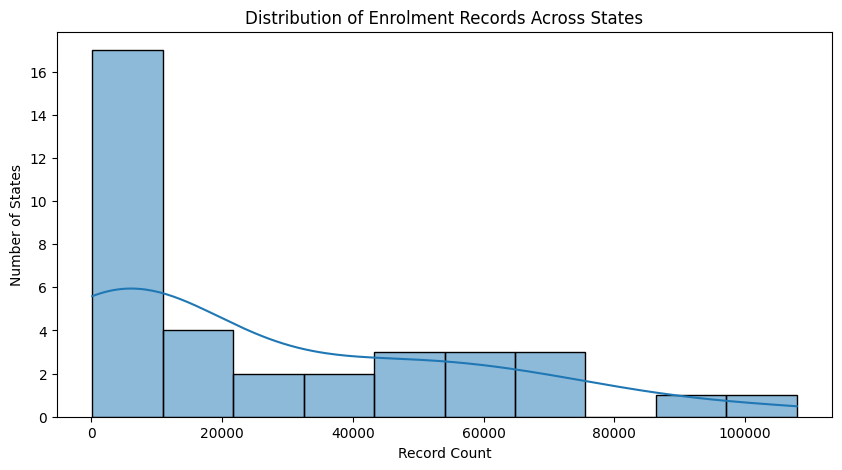

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(enrol_state['enrol_count'], bins=10, kde=True)
plt.title('Distribution of Enrolment Records Across States')
plt.xlabel('Record Count')
plt.ylabel('Number of States')
plt.show()

Aadhaar enrolment records are unevenly distributed across states, with a small number of large states accounting for most enrolments, while many states and Union Territories have relatively low counts.

Interpretation:

This confirms regional concentration of enrolment activity, where a few large states dominate the dataset. It supports the presence of structural disparity in enrolment distribution.

### **Outliers Detection Using Box Plot**

In [ ]:
def box_plot(df):
    count_cols = [
        'age_0_5',
        'age_5_17',
        'age_18_greater',
        'total_enrolment'
    ]

    for i in count_cols:
        if i not in df.columns:
            continue

        plt.figure(figsize=(8, 4))
        sns.boxplot(y=df[i])
        plt.yscale('log')
        plt.title(f'Log-Scale Boxplot of {i}')
        plt.ylabel(i)
        plt.show()

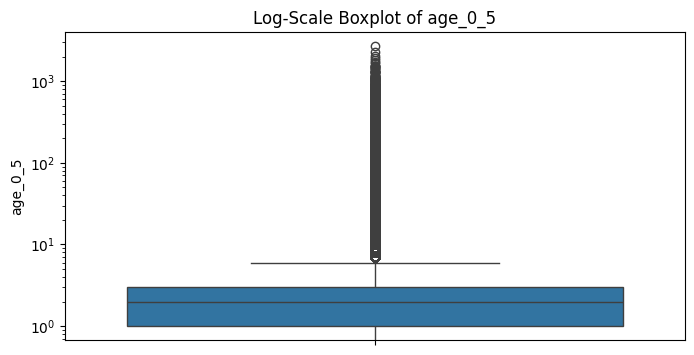

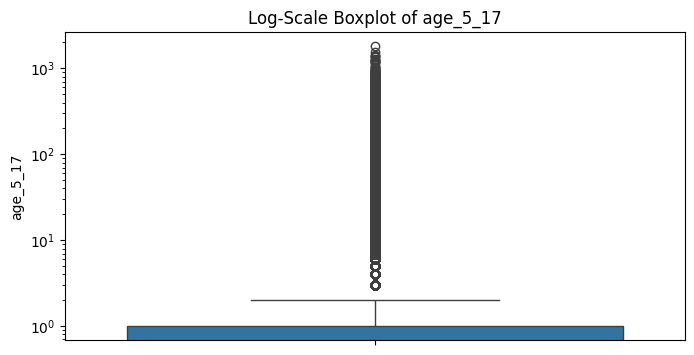

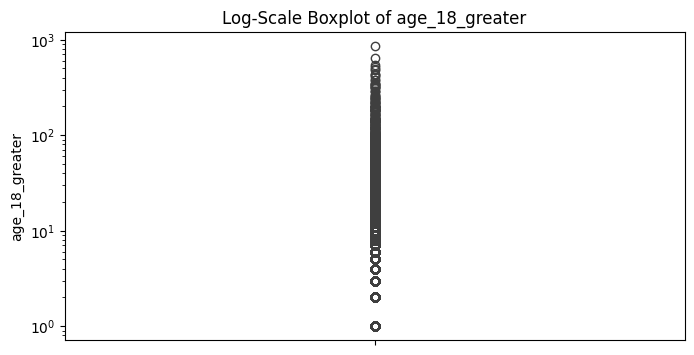

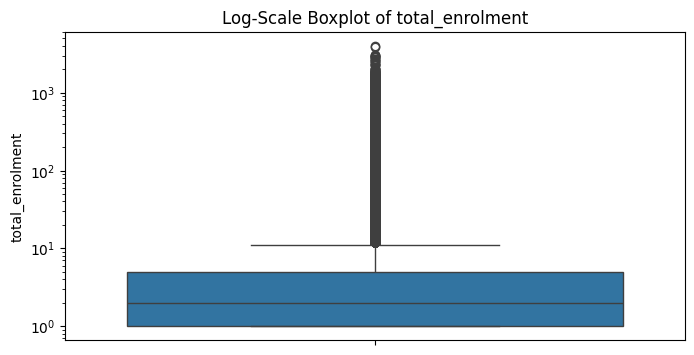

In [ ]:
box_plot(enrol_df_cleaned)

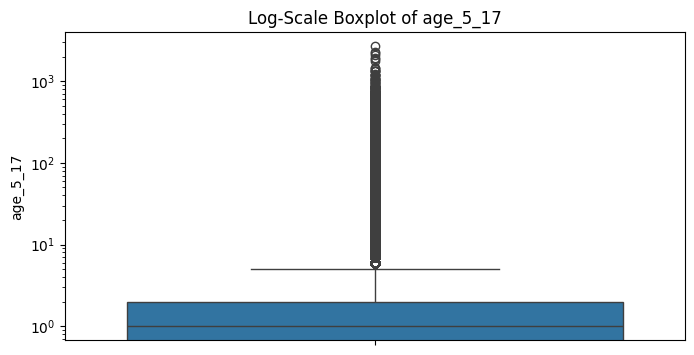

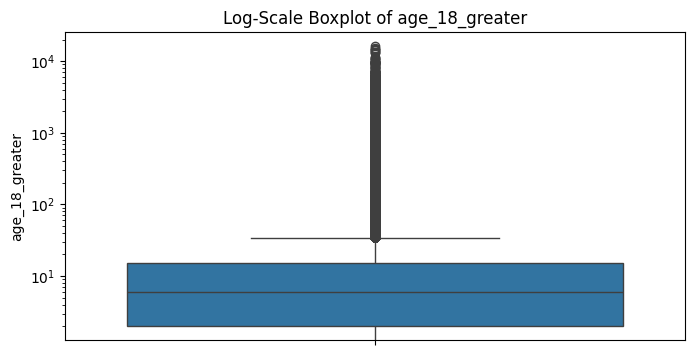

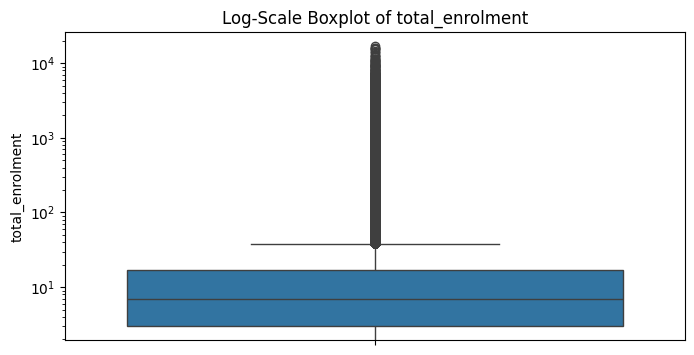

In [ ]:
box_plot(demo_df_cleaned)

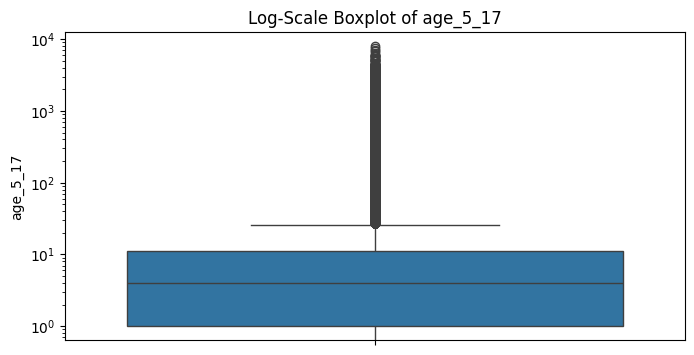

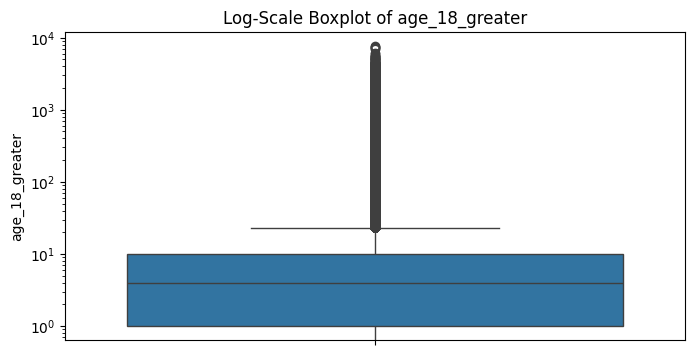

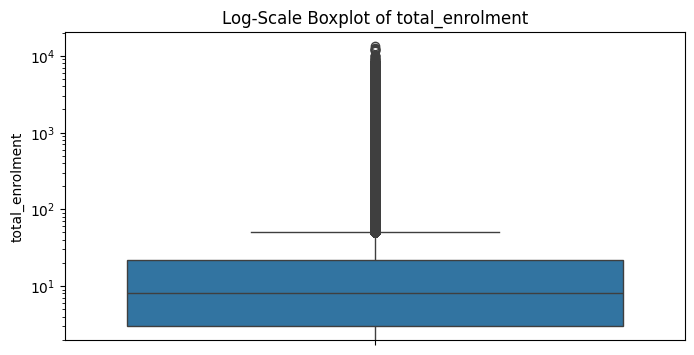

In [ ]:
box_plot(bio_df_cleaned)

Comment:
Multiple outliers are observed in age-group counts and total enrolment.
The spread of values is wide, especially for total enrolment.
Interpretation:

These outliers are not errors, but represent high-load districts or states. Since the dataset is real-world administrative data, removing them would distort actual patterns. Hence, they are retained for analysis.

### **Stats by states**

In [ ]:
def enrolment_stats_by_state(df):
    return (
        df.groupby('state')['total_enrolment']
        .agg(max='max',min='min',mean='mean')
        .reset_index()
    )

In [ ]:
enrolment_stats_by_state(enrol_df_cleaned)

,state,max,min,mean
0,Andaman And Nicobar Islands,11,1,1.330508
1,Andhra Pradesh,332,1,1.957877
2,Arunachal Pradesh,401,1,2.730200
3,Assam,1389,1,7.341749
4,Bihar,1871,1,10.144270
5,Chandigarh,117,1,3.171913
6,Chhattisgarh,1476,1,5.551586
7,Dadra And Nagar Haveli And Daman And Diu,467,1,4.541237
8,Delhi,2874,1,14.163326
9,Goa,42,1,1.530201


In [ ]:
enrolment_stats_by_state(demo_df_cleaned)

,state,max,min,mean
0,Andaman And Nicobar Islands,219,1,4.163563
1,Andhra Pradesh,2179,0,10.670915
2,Arunachal Pradesh,425,0,7.868902
3,Assam,2752,0,15.929833
4,Bihar,5924,0,48.821837
5,Chandigarh,1896,0,37.366536
6,Chhattisgarh,16942,0,52.106349
7,Dadra And Nagar Haveli And Daman And Diu,642,0,7.764957
8,Delhi,16094,0,122.212349
9,Goa,606,0,6.010202


In [ ]:
enrolment_stats_by_state(bio_df_cleaned)

,state,max,min,mean
0,Andaman And Nicobar Islands,376,1,12.079346
1,Andhra Pradesh,3884,0,22.668664
2,Arunachal Pradesh,629,1,17.705080
3,Assam,2034,0,21.278536
4,Bihar,6332,1,61.210685
5,Chandigarh,4885,1,46.670051
6,Chhattisgarh,5589,1,85.178438
7,Dadra And Nagar Haveli And Daman And Diu,2795,1,31.718137
8,Delhi,13381,1,144.715390
9,Goa,736,1,13.041740


Comment:
Significant variation exists between maximum, minimum, and mean enrolment values across states.
Some states exhibit very high maximum values compared to their mean.
Interpretation:

This indicates internal inequality within states, where certain districts contribute disproportionately to total enrolment, reinforcing the presence of localized concentration.

#Age-Group Statistics by State

In [ ]:
def age_group_stats_by_state(df):
    age_cols = [
        'age_0_5',
        'age_5_17',
        'age_18_greater'
    ]

    existing_age_cols = [c for c in age_cols if c in df.columns]

    return (
        df.groupby('state')[existing_age_cols]
        .agg(['max', 'min', 'mean'])
        .reset_index()
    )

In [ ]:
age_group_stats_by_state(enrol_df_cleaned)

state age_0_5                age_5_17  \
                                                 max min       mean      max   
0                Andaman And Nicobar Islands       9   0   1.240113        2   
1                             Andhra Pradesh     222   0   1.721474      108   
2                          Arunachal Pradesh      46   0   1.232453      322   
3                                      Assam    1152   0   4.494869      508   
4                                      Bihar     877   0   4.355106     1229   
5                                 Chandigarh      86   0   2.877724       21   
6                               Chhattisgarh    1156   0   4.431942      309   
7   Dadra And Nagar Haveli And Daman And Diu     360   0   3.773196       92   
8                                      Delhi    1826   0  10.342191     1029   
9                                        Goa      21   0   1.255705       10   
10                                   Gujarat     863   0   4.177634      919   
11                                   Haryana    1528   0   5.483956      351   
12                          Himachal Pradesh      57   0   1.598906       24   
13                         Jammu And Kashmir     308   0   3.514081      260   
14                                 Jharkhand     994   0   4.250687     1023   
15                                 Karnataka     560   0   2.611987      263   
16                                    Kerala     135   0   1.372736      121   
17                                    Ladakh      13   0   1.532895        5   
18                               Lakshadweep       5   0   1.205128        2   
19                            Madhya Pradesh    1400   0   7.344628     1376   
20                               Maharashtra    2262   0   3.634800     1549   
21                                   Manipur     348   0   1.603816     1265   
22                                 Meghalaya     573   0   5.729201     1812   
23                                   Mizoram     275   0   2.802495       76   
24                                  Nagaland     249   0   2.282419      455   
25                                    Odisha     327   0   2.147381      103   
26                                Puducherry      15   0   1.525904        3   
27                                    Punjab    1293   0   3.020866      400   
28                                 Rajasthan    1292   0   4.103366      667   
29                                    Sikkim     100   0   1.251012      147   
30                                Tamil Nadu     264   0   1.978243       76   
31                                 Telangana     936   0   2.482898      362   
32                                   Tripura     166   0   1.972192      144   
33                             Uttar Pradesh    2688   0   4.741083     1434   
34                               Uttarakhand    1298   0   3.184686      323   
35                               West Bengal    1734   0   3.617265     1207   

                  age_18_greater                
   min       mean            max min      mean  
0    0   0.090395              0   0  0.000000  
1    0   0.213098             45   0  0.023305  
2    0   1.401159             33   0  0.096587  
3    0   2.112070            308   0  0.734810  
4    0   5.587572            263   0  0.201592  
5    0   0.254237             10   0  0.039952  
6    0   1.010462            184   0  0.109182  
7    0   0.639175             15   0  0.128866  
8    0   3.351671            199   0  0.469464  
9    0   0.169799             11   0  0.104698  
10   0   1.556092            197   0  0.355778  
11   0   0.573196             52   0  0.069330  
12   0   0.064644             33   0  0.017703  
13   0   0.697541             20   0  0.046670  
14   0   2.487900             34   0  0.062583  
15   0   0.503931            168   0  0.152043  
16   0   0.476338             31   0  0.068497  
17   0   0.437500              2   0  0.059211  
18   0   0.064103 

In [ ]:
age_group_stats_by_state(demo_df_cleaned)

state age_5_17                 \
                                                  max min       mean   
0                Andaman And Nicobar Islands       26   0   0.378947   
1                             Andhra Pradesh      446   0   1.481023   
2                          Arunachal Pradesh       53   0   1.263304   
3                                      Assam      312   0   1.328474   
4                                      Bihar      637   0   3.835657   
5                                 Chandigarh      589   0   5.771484   
6                               Chhattisgarh      852   0   4.318388   
7   Dadra And Nagar Haveli And Daman And Diu       78   0   1.223077   
8                                      Delhi     2690   0  14.990197   
9                                        Goa      156   0   0.567180   
10                                   Gujarat      850   0   2.065651   
11                                   Haryana     1045   0   4.398774   
12                          Himachal Pradesh      130   0   0.688607   
13                         Jammu And Kashmir      698   0   2.596340   
14                                 Jharkhand      413   0   2.453525   
15                                 Karnataka     1338   0   1.654636   
16                                    Kerala       85   0   0.571915   
17                                    Ladakh      113   0   1.568452   
18                               Lakshadweep        3   0   0.319512   
19                            Madhya Pradesh     1079   0   4.825070   
20                               Maharashtra      799   0   1.619344   
21                                   Manipur      393   0   5.565111   
22                                 Meghalaya      254   0   1.479426   
23                                   Mizoram      278   0   1.346512   
24                                  Nagaland      139   0   1.028305   
25                                    Odisha      165   0   1.388838   
26                                Puducherry       86   0   0.968168   
27                                    Punjab      684   0   1.076158   
28                                 Rajasthan      610   0   2.765073   
29                                    Sikkim       34   0   0.458730   
30                                Tamil Nadu      375   0   1.582985   
31                                 Telangana      571   0   2.599440   
32                                   Tripura      106   0   1.304079   
33                             Uttar Pradesh     1398   0   4.561371   
34                               Uttarakhand      678   0   2.036707   
35                               West Bengal      493   0   1.427359   

   age_18_greater                  
              max min        mean  
0             201   0    3.784615  
1            1911   0    9.189892  
2             387   0    6.605599  
3            2465   0   14.601359  
4            5533   0   44.986181  
5            1538   0   31.595052  
6           16166   0   47.787961  
7             593   0    6.541880  
8           14314   0  107.222151  
9             470   0    5.443021  
10           6316   0   16.011740  
11           6056   0   32.566582  
12            768   0    4.596266  
13           3103   0   15.813128  
14           7256   0   31.710341  
15           1902   0    8.922390  
16            676   0    6.410754  
17            320   0    5.092262  
18              9   0    1.907317  
19           3708   0   30.224497  
20           5638   0   28.697597  
21           1456   0   35.065460  
22           1771   0   13.817464  
23           1196   0    9.137209  
24           1014   0    7.834674  
25           1870   0    9.090732  
26            519   0    5.660642  
27           7070   0   15.854754  
28           9080   0   27.327360  
29            262   0    4.284127  
30           2259   0    9.442441  
31           2746   0   15.060298  
32           1778   0   13.715743  
33          14732   0   44.271834  
34    

In [ ]:
age_group_stats_by_state(bio_df_cleaned)

state age_5_17                 \
                                                  max min       mean   
0                Andaman And Nicobar Islands      207   0   6.871593   
1                             Andhra Pradesh     3309   0  13.698455   
2                          Arunachal Pradesh      336   0  10.397523   
3                                      Assam     1644   0  12.925075   
4                                      Bihar     3583   0  27.673028   
5                                 Chandigarh     4214   0  30.892766   
6                               Chhattisgarh     1220   0  27.938790   
7   Dadra And Nagar Haveli And Daman And Diu     1126   0  13.238562   
8                                      Delhi     6921   0  63.600492   
9                                        Goa      325   0   6.494807   
10                                   Gujarat     2585   0  16.996395   
11                                   Haryana     4567   0  26.984970   
12                          Himachal Pradesh      592   0   6.415383   
13                         Jammu And Kashmir     1598   0  21.472362   
14                                 Jharkhand     3225   0  24.672665   
15                                 Karnataka     1377   0   9.135455   
16                                    Kerala      604   0   6.790234   
17                                    Ladakh       86   0   4.000000   
18                               Lakshadweep       89   0   4.180952   
19                            Madhya Pradesh     7085   0  47.725483   
20                               Maharashtra     4469   0  23.943754   
21                                   Manipur     3271   0  25.970250   
22                                 Meghalaya      924   0   8.941982   
23                                   Mizoram     3043   0  26.343177   
24                                  Nagaland      536   0   8.730224   
25                                    Odisha     1428   0  12.478160   
26                                Puducherry      160   0   5.613396   
27                                    Punjab     2982   0  14.898897   
28                                 Rajasthan     2547   0  26.507850   
29                                    Sikkim      283   0   5.962766   
30                                Tamil Nadu     1880   0  12.325197   
31                                 Telangana     1244   0  11.707636   
32                                   Tripura     1384   0  18.134248   
33                             Uttar Pradesh     8002   0  41.306618   
34                               Uttarakhand     2748   0  19.051514   
35                               West Bengal     1292   0   8.201510   

   age_18_greater                 
              max min       mean  
0             246   0   5.207753  
1             870   0   8.970209  
2             536   0   7.307556  
3            1211   0   8.353460  
4            2879   0  33.537657  
5             671   0  15.777284  
6            4619   0  57.239649  
7            1793   0  18.479575  
8            7625   0  81.114898  
9             504   0   6.546933  
10           2498   0  20.211413  
11           4587   0  36.813778  
12            719   0   7.010211  
13           1735   0  19.263872  
14           3512   0  32.336332  
15           1158   0  10.215548  
16           1842   0  10.090592  
17            143   0   4.225291  
18            123   0   4.857143  
19           5534   0  40.485691  
20           7472   0  38.896648  
21           2711   0  18.159629  
22           3265   0  12.615289  
23            760   0  10.697544  
24           1334   0  20.803601  
25           1462   0  12.988089  
26            350   0   8.882577  
27           4266   0  22.192727  
28           3020   0  24.713807  
29             82   0   3.104610  
30           2265   0  13.845507  
31           1118   0   9.888110  
32           1111   0  17.764217  
33           4980   0  22.369314  
34           3971   0  15.514862  
35     

Comment:
Adult (18+) enrolment consistently dominates across states.
Child (0–5) enrolment is comparatively lower in most states.
Interpretation:

This highlights demographic imbalance, where enrolment activity is largely driven by adults. It may indicate lower early-age registration or delayed enrolment practices.

### **Top 5 states by enrolment**

In [ ]:
def top_states_by_total_enrolment(df, n=5):

    top_states = (
        df.groupby('state')['total_enrolment'].sum().sort_values(ascending=False).head(n).reset_index()
    )
    display(top_states)

    fig = px.bar(
        top_states,
        x='state',
        y='total_enrolment',
        title=f'Top {n} States by Total Enrollment',
        labels={'state': 'State', 'total_enrolment': 'Total Enrollment'},
        color='total_enrolment',
        color_continuous_scale='Blues',
        text='total_enrolment'
    )

    fig.update_traces(textposition='outside')
    fig.update_layout(
        xaxis_tickangle=-45,
        title_x=0.5
    )

    fig.show()

In [ ]:
top_states_by_total_enrolment(enrol_df_cleaned)

,state,total_enrolment
0,Uttar Pradesh,1002436
1,Bihar,593734
2,Madhya Pradesh,487682
3,West Bengal,367975
4,Maharashtra,363327


In [ ]:
top_states_by_total_enrolment(demo_df_cleaned)

,state,total_enrolment
0,Uttar Pradesh,6460340
1,Maharashtra,3824664
2,Bihar,3638838
3,West Bengal,2842112
4,Madhya Pradesh,2104411


In [ ]:
top_states_by_total_enrolment(bio_df_cleaned)

,state,total_enrolment
0,Uttar Pradesh,9367048
1,Maharashtra,9020614
2,Madhya Pradesh,5819644
3,Bihar,4778963
4,Tamil Nadu,4571708


Comment:
A small number of states contribute the majority of total enrolment.
These states are typically highly populated and urbanized.
Interpretation:

This confirms regional dominance, where enrolment activity is concentrated in a few key states, supporting the hypothesis of state-wise disparity.

### **Top 5 district by enrolment**

In [ ]:
def top_district_by_total_enrolment(df, n=5):

    top_districts = (
        df.groupby('district')['total_enrolment'].sum().sort_values(ascending=False).head(n).reset_index()
    )
    display(top_districts)

    fig = px.bar(
        top_districts,
        x='district',
        y='total_enrolment',
        title=f'Top {n} Districts by Total Enrollment',
        labels={'district': 'District', 'total_enrolment': 'Total Enrollment'},
        color='total_enrolment',
        color_continuous_scale='Blues',
        text='total_enrolment'
    )

    fig.update_traces(textposition='outside')
    fig.update_layout(
        xaxis_tickangle=-45,
        title_x=0.5
    )

    fig.show()

In [ ]:
top_district_by_total_enrolment(enrol_df_cleaned)

,district,total_enrolment
0,West Champaran,46271
1,East Champaran,43767
2,Thane,43142
3,Sitamarhi,41652
4,Bahraich,38897


In [ ]:
top_district_by_total_enrolment(demo_df_cleaned)

,district,total_enrolment
0,South 24 Parganas,330814
1,Thane,326750
2,Pune,326083
3,Murshidabad,263029
4,Bengaluru,260983


In [ ]:
top_district_by_total_enrolment(bio_df_cleaned)

,district,total_enrolment
0,Pune,593592
1,Nashik,561893
2,Thane,559311
3,Bengaluru,490635
4,Ahmedabad,414421


Top 5 Districts by Total Enrolment

Comment:
Top districts show significantly higher enrolment than others.
A steep difference exists between top-ranked and remaining districts.

Interpretation:

This indicates operational concentration in specific districts, typically metro or high-density areas. These districts act as high-load zones requiring more infrastructure

### **Get the record when total enrolment is maximum**

In [ ]:
def max_total_enrolment(df):
    return df[df['total_enrolment'] == df['total_enrolment'].max()]

In [ ]:
max_total_enrolment(enrol_df_cleaned)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolment,% toddlers (0–5),% school-age (5–17),% adults (18+)
2976,2025-07-01,Uttar Pradesh,Moradabad,244001,2688,1254,23,3965,67.79319,31.626734,0.580076


In [ ]:
max_total_enrolment(demo_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
748440,2025-06-01,Chhattisgarh,Kondagaon,494226,776,16166,16942,4.580333,95.419667


In [ ]:
max_total_enrolment(bio_df_cleaned)

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+)
24436,2025-04-01,Delhi,South Delhi,110062,5861,7520,13381,43.800912,56.199088


Comment:
Specific records show extremely high total enrolment values compared to others.

Interpretation:

These represent peak operational instances, likely from highly active districts or specific high-volume periods, and contribute to overall skewness in data.

### **Rank State And then whithin State Rank Districts**

In [ ]:
def rank_state_and_district(df, state_name=None, state_rank=None):
    df = df.copy()

    # remove date duplicates by summing enrolment for each district
    df = df.groupby(['state','district'], as_index=False)['total_enrolment'].sum()

    # calculate total enrolment for each state
    state_totals = df.groupby('state')['total_enrolment'].sum().reset_index(name='state_total_enrolment')

    # rank states based on total enrolment
    state_totals['state_rank'] = state_totals['state_total_enrolment'].rank(method='dense', ascending=False).astype('Int64')

    # merge state rank back to main dataframe
    df = df.merge(state_totals[['state','state_rank']], on='state', how='left')

    # rank districts within each state
    df['district_rank_within_state'] = df.groupby('state')['total_enrolment'].rank(method='dense', ascending=False).astype('Int64')

    # rank districts across all states
    df['overall_district_rank'] = df['total_enrolment'].rank(method='dense', ascending=False).astype('Int64')

    if state_name is not None:
        df = df[df['state'].str.lower() == state_name.lower()]

    if state_rank is not None:
        df = df[df['state_rank'] == state_rank]

    # sort final output
    df = df.sort_values(['state_rank','district_rank_within_state'])

    return df[['state','state_rank','district', 'district_rank_within_state', 'overall_district_rank', 'total_enrolment']].reset_index(drop=True)

#**How To Use**
### rank_state_and_district(enrol_df)
### rank_state_and_district(enrol_df, state_name="Punjab")
### rank_state_and_district(enrol_df, state_rank=1)

In [ ]:
rank_state_and_district(enrol_df_cleaned)

,state,state_rank,district,district_rank_within_state,overall_district_rank,total_enrolment
0,Uttar Pradesh,1,Bahraich,1,5,38897
1,Uttar Pradesh,1,Sitapur,2,12,30475
2,Uttar Pradesh,1,Agra,3,14,29345
3,Uttar Pradesh,1,Bareilly,4,17,27357
4,Uttar Pradesh,1,Aligarh,5,20,25851
...,...,...,...,...,...,...
812,Ladakh,34,Leh,2,746,125
813,Andaman And Nicobar Islands,35,South Andaman,1,722,267
814,Andaman And Nicobar Islands,35,North And Middle Andaman,2,745,129
815,Andaman And Nicobar Islands,35,Nicobar,3,759,75


In [ ]:
rank_state_and_district(enrol_df_cleaned, state_name="Punjab")

,state,state_rank,district,district_rank_within_state,overall_district_rank,total_enrolment
0,Punjab,19,Ludhiana,1,62,17457
1,Punjab,19,Amritsar,2,188,9544
2,Punjab,19,Gurdaspur,3,367,5089
3,Punjab,19,Patiala,4,368,5087
4,Punjab,19,Hoshiarpur,5,417,4086
5,Punjab,19,Jalandhar,6,421,4034
6,Punjab,19,S.A.S. Nagar,7,433,3840
7,Punjab,19,Kapurthala,8,443,3681
8,Punjab,19,Tarn Taran,9,491,2905
9,Punjab,19,Bathinda,10,509,2657


In [ ]:
rank_state_and_district(enrol_df_cleaned, state_rank=1)

,state,state_rank,district,district_rank_within_state,overall_district_rank,total_enrolment
0,Uttar Pradesh,1,Bahraich,1,5,38897
1,Uttar Pradesh,1,Sitapur,2,12,30475
2,Uttar Pradesh,1,Agra,3,14,29345
3,Uttar Pradesh,1,Bareilly,4,17,27357
4,Uttar Pradesh,1,Aligarh,5,20,25851
...,...,...,...,...,...,...
72,Uttar Pradesh,1,Auraiya,73,445,3660
73,Uttar Pradesh,1,Hamirpur,74,458,3372
74,Uttar Pradesh,1,Mahoba,75,486,2938
75,Uttar Pradesh,1,Shravasti,76,519,2535


Comment:
Districts within each state show clear ranking based on enrolment.
A few districts dominate within each state.

Interpretation:

This highlights intra-state disparity, where enrolment is not evenly distributed even within the same state, indicating localized administrative or population differences.

In [ ]:
enrol_df_cleaned['state'].unique()

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu And Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'Dadra And Nagar Haveli And Daman And Diu', 'Arunachal Pradesh',
       'Himachal Pradesh', 'Goa', 'Ladakh', 'Andaman And Nicobar Islands',
       'Puducherry', 'Lakshadweep'], dtype=object)

## **Region Mapping**

In [ ]:
region_map = {
    # NORTH
    'Jammu And Kashmir': 'North',
    'Ladakh': 'North',
    'Himachal Pradesh': 'North',
    'Punjab': 'North',
    'Chandigarh': 'North',
    'Haryana': 'North',
    'Delhi': 'North',
    'Uttarakhand': 'North',
    'Uttar Pradesh': 'North',
    'Rajasthan': 'North',

    # WEST
    'Gujarat': 'West',
    'Maharashtra': 'West',
    'Goa': 'West',
    'Dadra And Nagar Haveli And Daman And Diu': 'West',

    # CENTRAL
    'Madhya Pradesh': 'Central',
    'Chhattisgarh': 'Central',

    # EAST
    'Bihar': 'East',
    'Jharkhand': 'East',
    'West Bengal': 'East',
    'Odisha': 'East',
    'Sikkim': 'East',

    # SOUTH
    'Andhra Pradesh': 'South',
    'Telangana': 'South',
    'Tamil Nadu': 'South',
    'Karnataka': 'South',
    'Kerala': 'South',
    'Puducherry': 'South',
    'Lakshadweep': 'South',
    'Andaman And Nicobar Islands': 'South',

    # NORTH-EAST
    'Assam': 'North-East',
    'Arunachal Pradesh': 'North-East',
    'Manipur': 'North-East',
    'Meghalaya': 'North-East',
    'Mizoram': 'North-East',
    'Nagaland': 'North-East',
    'Tripura': 'North-East',
}

Comment:
States were grouped into broader regions: North, South, East, West, Central, and North-East.
The distribution shows uneven representation across regions.

Interpretation:

This transformation enables macro-level analysis, allowing comparison beyond individual states and helping identify regional disparities in enrolment patterns.

In [ ]:
enrol_df_cleaned['region'] = enrol_df_cleaned['state'].map(region_map)
enrol_df_cleaned.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolment,% toddlers (0–5),% school-age (5–17),% adults (18+),region
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,10.091743,55.963303,33.944954,North-East
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,16.279070,38.372093,45.348837,South
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,23.577236,66.666667,9.756098,North
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,58.490566,27.358491,14.150943,North
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,27.450980,31.372549,41.176471,South


In [ ]:
demo_df_cleaned['region'] = demo_df_cleaned['state'].map(region_map)
demo_df_cleaned.head()

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+),region
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,8.477509,91.522491,North
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,5.541562,94.458438,South
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,7.831325,92.168675,West
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,7.100592,92.899408,South
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,5.421687,94.578313,North


In [ ]:
bio_df_cleaned['region'] = bio_df_cleaned['state'].map(region_map)
bio_df_cleaned.head()

,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+),region
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,32.672112,67.327888,North
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,28.070175,71.929825,East
2,2025-03-01,Jammu And Kashmir,Punch,185101,643,1091,1734,37.081892,62.918108,North
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,20.711974,79.288026,East
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,24.953959,75.046041,South


### **Check Region Distribution**

In [ ]:
def plot_check_region_distribution(df, column, title="Distribution"):
    # Prepare data
    counts = df[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    # Create consistent color map
    categories = counts[column].tolist()
    colors = px.colors.qualitative.Plotly
    color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}

    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "xy"}, {"type": "domain"}]],
        subplot_titles=("Bar Chart", "Pie Chart")
    )

    # Bar chart
    bar_fig = px.bar(
        counts.sort_values(by='count'),
        x='count',
        y=column,
        orientation='h',
        color=column,
        color_discrete_map=color_map
    )

    for trace in bar_fig.data:
        fig.add_trace(trace, row=1, col=1)

    # Pie chart
    pie_fig = px.pie(
        counts,
        names=column,
        values='count',
        color=column,
        color_discrete_map=color_map
    )

    for trace in pie_fig.data:
        fig.add_trace(trace, row=1, col=2)

    # Layout fixes
    fig.update_layout(
        title_text=title,
        width=1000,
        height=500,
        barmode='overlay'
    )

    return fig

In [ ]:
print("Number of Entries per Region In Enrolment Dataset:")
display(enrol_df_cleaned['region'].value_counts())

Number of Entries per Region In Enrolment Dataset:


,count
region,
South,300990
North,236827
East,200892
West,122457
Central,67403
North-East,46097


Comment:

The South region has the highest number of entries approx.300,990, followed by North approx.236,827 and East approx.200,892.
West approx.122,457 and Central approx.67,403 contribute moderate to low entries.
North-East approx.46,097 has the lowest representation in the dataset.

Interpretation:

This indicates a clear regional imbalance, where southern and northern regions dominate Aadhaar enrolment activity. The North-East region is significantly underrepresented, which may reflect lower population density, accessibility challenges, or infrastructure limitations.

In [ ]:
plot_check_region_distribution(enrol_df_cleaned, 'region', "Enrolment distribution of Entries per Region")

Comment:
The bar chart shows South region clearly dominating enrolment counts.
Pie chart confirms proportional contribution:
South ≈ 30.9%
North ≈ 24.3%
East ≈ 20.6%
West ≈ 12.6%
Central ≈ 6.9%
North-East ≈ 4.7%

Interpretation:

Enrolment activity is heavily concentrated in South and North regions, contributing over 50% of total entries combined. The long-tail distribution highlights regional disparity, supporting the need for targeted policy intervention in underrepresented regions.

In [ ]:
print("Number of Entries per Region in Demographic Dataset:")
display(demo_df_cleaned['region'].value_counts())

Number of Entries per Region in Demographic Dataset:


,count
region,
South,582229
North,326650
East,312272
West,207058
Central,87319
North-East,74014


In [ ]:
plot_check_region_distribution(demo_df_cleaned, 'region', "Demograpic distribution of Entries per Region")

Comment:
South region again shows the highest demographic update activity.
Pie chart distribution:
South ≈ 36.6% (highest)
North ≈ 20.5%
East ≈ 19.6%
West ≈ 13%
Central ≈ 5.49%
North-East ≈ 4.66%

Interpretation:

Demographic updates are even more concentrated in the South region compared to enrolment, indicating higher update frequency and digital engagement. This suggests that residents in the South may be more proactive in updating Aadhaar details.

In [ ]:
print("Number of Entries per Region in Biometric Dataset:")
display(bio_df_cleaned['region'].value_counts())

Number of Entries per Region in Biometric Dataset:


,count
region,
South,646746
North,375051
East,334100
West,234477
Central,96018
North-East,73474


In [ ]:
plot_check_region_distribution(bio_df_cleaned, 'region', "Biometric distribution of Entries per Region")

Comment:
Similar pattern observed as previous datasets.
Pie chart distribution:
South ≈ 36.7%
North ≈ 21.3%
East ≈ 19%
West ≈ 13.3%
Central ≈ 5.46%
North-East ≈ 4.17%

Interpretation:

Biometric updates follow the same regional trend as demographic updates, confirming that regions with high enrolment also show high update activity. This indicates strong correlation between enrolment volume and update frequency.

In [ ]:
enrol_df_cleaned.groupby(['state','district'])[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

age_0_5  age_5_17  \
state                       district                                      
Andaman And Nicobar Islands Nicobar                        64        11   
                            North And Middle Andaman      125         4   
                            South Andaman                 250        17   
Andhra Pradesh              Adilabad                     1115       279   
                            Alluri Sitharama Raju        1064       116   
...                                                       ...       ...   
West Bengal                 South 24 Parganas           27814      9302   
                            South Dinajpur               5609      1127   
                            Uttar Dinajpur               6478      4859   
                            West Bardhaman                856       317   
                            West Medinipur              15809      4464   

                                                      age_18_greater  
state                       district                                  
Andaman And Nicobar Islands Nicobar                                0  
                            North And Middle Andaman               0  
                            South Andaman                          0  
Andhra Pradesh              Adilabad                               1  
                            Alluri Sitharama Raju                 34  
...                                                              ...  
West Bengal                 South 24 Parganas                    330  
                            South Dinajpur                        99  
                            Uttar Dinajpur                       334  
                            West Bardhaman                        93  
                            West Medinipur                       173  

[817 rows x 3 columns]

### **Total footfall over time and average footfall per day**

In [ ]:
def get_state_data(df, state_name):
    age_cols = [c for c in ['age_0_5','age_5_17','age_18_greater'] if c in df.columns]

    df_state = (df.query(f"state == '{state_name}'").groupby(['state','district'])[age_cols].agg(['sum','mean']))
    display(df_state)

    plot_df = df_state.xs('sum', axis=1, level=1).reset_index()

    fig = px.bar(plot_df, x="district", y=age_cols,
        title=f"Enrollment Composition by District ({state_name})",
        barmode="stack")

    fig.update_layout(xaxis_tickangle=45)
    fig.show()

In [ ]:
get_state_data(enrol_df_cleaned, 'Bihar')

age_0_5            age_5_17            age_18_greater  \
                         sum       mean      sum       mean            sum   
state district                                                               
Bihar Araria            9646   9.143128     5357   5.077725            124   
      Arwal              777   1.387500     2939   5.248214             33   
      Aurangabad        2921   1.797538     6925   4.261538             72   
      Banka             5945   4.524353     4669   3.553272             79   
      Begusarai         7719   4.605609     4851   2.894391             55   
      Bhagalpur        10196   5.903880    10025   5.804864            375   
      Bhojpur           3043   1.357270     9832   4.385370            104   
      Buxar             2407   1.698659     4453   3.142555             60   
      Darbhanga         9633   4.114908     5466   2.334900             68   
      East Champaran   14002   5.444012    28173  10.953733           1592   
      Gaya              6540   3.236022    19786   9.790203            434   
      Gopalganj         5195   3.977795     9461   7.244257            192   
      Jamui             5042   6.590850     4897   6.401307            159   
      Jehanabad          888   0.866341     3683   3.593171            139   
      Kaimur Bhabua     2938   4.282799     4631   6.750729             84   
      Katihar          10877   8.209057     4757   3.590189            113   
      Khagaria          4167   4.599338     3653   4.032009             67   
      Kishanganj        6527  13.185859     1680   3.393939             23   
      Lakhisarai        2599   5.156746     3364   6.674603             68   
      Madhepura         4371   4.424089     4225   4.276316             38   
      Madhubani        12324   4.831047    12275   4.811838            791   
      Munger            2397   3.525000     3466   5.097059            102   
      Muzaffarpur      13787   4.824003    13854   4.847446            657   
      Nalanda           3527   2.120866    10452   6.285027            134   
      Nawada            2661   1.904796    12099   8.660702            288   
      Patna             6559   2.002137    16758   5.115385            744   
      Purnia           11969   7.128648     7685   4.577129            183   
      Rohtas            2623   1.623144     4974   3.077970             76   
      Saharsa           6054   5.760228     6335   6.027593            201   
      Samastipur       10877   4.394747     7570   3.058586            131   
      Saran             7401   2.454726    16040   5.320066            217   
      Sheikhpura        1191   2.756944     1863   4.312500             19   
      Sheohar           1900   5.539359     1119   3.262391             11   
      Sitamarhi        20358  12.558914    18600  11.474399           2694   
      Siwan             5961   2.466281     8778   3.631775            135   
      Supaul            5473   4.030191     4408   3.245950            155   
      Vaishali          7972   3.586145     9424   4.239316             52   
      West Champaran   16433  12.411631    28508  21.531722           1330   

                                
                          mean  
state district                  
Bihar Araria          0.117536  
      Arwal           0.058929  
      Aurangabad      0.044308  
      Banka           0.060122  
      Begusarai       0.032816  
      Bhagalpur       0.217140  
      Bhojpur         0.046387  
      Buxar           0.042343  
      Darbhanga       0.029047  
      East Champaran  0.618974  
      Gaya            0.214745  
      Gopalganj       0.147014  
      Jamui           0.207843  
      Jehanabad       0.135610  
      Kaimur Bhabua   0.122449  
      Katihar         0.085283  
      Khagaria        0.073951  
      Kishanganj      0.046465  
      Lakhisarai      0.134921  
      Madhepura       0.038462  
      Madhubani       0.310074  
      Munger          0.150000

Visualization Insight (Stacked Bar Chart)
Comment:
The stacked bar chart clearly shows:
Large variation in total enrolment between districts
Dominance of age 5–17 segment (middle portion of bars)
Minimal contribution of age 18+ (top segment)
Interpretation:

This visualization confirms that:

Enrolment distribution is not uniform across districts
Younger population segments are the primary contributors to enrolment volume
District-level planning is essential since state-level aggregation hides these disparities

Certain districts such as:

West Champaran
East Champaran
Sitamarhi
Muzaffarpur

show very high enrolment counts across all age groups, especially in the 5–17 category.

The age group 5–17 consistently dominates across most districts, indicating higher enrolment among school-age individuals.
The adult category (18+) is significantly lower across all districts compared to younger groups.

Some districts like:

Arwal
Sheikhpura
Sheohar

show comparatively low enrolment across all categories, indicating low population or lower participation.

Interpretation:
The dominance of the 5–17 age group suggests that Aadhaar enrolment is strongly driven by school-age requirements, such as:
School admissions
Government schemes
Identity verification
The low adult enrolment proportion (18+) suggests:
Either adults were already enrolled earlier
Or lower update/enrolment activity in this category
High-performing districts like West Champaran and East Champaran indicate:
Higher population density
Better administrative reach
Stronger enrolment infrastructure
Low-performing districts highlight regional inequality at micro (district) level, not just state or region level.

In [ ]:
get_state_data(demo_df_cleaned, 'Bihar')

age_5_17           age_18_greater            
                          sum      mean            sum        mean
state district                                                    
Bihar Araria             7079  5.216654         114543   84.408990
      Arwal              1756  2.151961          20262   24.830882
      Aurangabad         7884  3.451839          71874   31.468476
      Banka              5189  2.748411          64051   33.925318
      Begusarai         10236  4.446568          91661   39.817984
      Bhagalpur         10660  4.731469          98331   43.644474
      Bhojpur            7773  2.665638          97961   33.594307
      Buxar              5229  2.776952          49026   26.036113
      Darbhanga          9550  3.242784         109274   37.104924
      East Champaran    13999  4.330034         175976   54.431178
      Gaya              14693  5.980057         129089   52.539276
      Gopalganj          6079  3.874442          74246   47.320586
      Jamui              4068  4.535117          46024   51.308807
      Jehanabad          3183  2.221214          30990   21.625960
      Kaimur Bhabua      4219  4.860599          47378   54.582949
      Katihar            8761  5.659561         126843   81.939922
      Khagaria           5747  5.421698          53920   50.867925
      Kishanganj         4537  8.015901         103820  183.427562
      Lakhisarai         2996  4.342029          33494   48.542029
      Madhepura          4941  3.890551          63945   50.350394
      Madhubani         10269  3.351501         126568   41.308094
      Munger             3047  3.315560          38743   42.157780
      Muzaffarpur       11962  3.281756         144301   39.588752
      Nalanda            9043  4.161528         110742   50.962724
      Nawada             5220  3.096085          61069   36.221234
      Patna             16295  3.505809         173838   37.400602
      Purnia             7464  3.335121         106162   47.436104
      Rohtas             7999  3.563029          81800   36.436526
      Saharsa            4874  3.810790          56556   44.218921
      Samastipur        11708  3.735801         142533   45.479579
      Saran             10944  3.044228         113831   31.663700
      Sheikhpura         1815  2.936893          20622   33.368932
      Sheohar            1946  4.633333          23123   55.054762
      Sitamarhi          9343  5.351088         116991   67.005155
      Siwan              7939  2.592750          84114   27.470281
      Supaul             4849  2.956707          75434   45.996341
      Vaishali           9332  3.698771         107274   42.518430
      West Champaran    13255  7.970535         166546  100.147925

In [ ]:
get_state_data(bio_df_cleaned, 'Bihar')

age_5_17            age_18_greater            
                          sum       mean            sum        mean
state district                                                     
Bihar Araria            70999  51.560639          80714   58.615832
      Arwal             11800  15.284974          18014   23.334197
      Aurangabad        45453  20.946083          48780   22.479263
      Banka             48937  25.238267          47217   24.351212
      Begusarai         71138  30.729158          72896   31.488553
      Bhagalpur         70610  29.605870          73623   30.869182
      Bhojpur           38520  12.759192          56162   18.602849
      Buxar             24348  12.661466          31522   16.392096
      Darbhanga         91683  28.858357         114191   35.943028
      East Champaran    93891  29.204044         113240   35.222395
      Gaya              84403  32.765140          96976   37.645963
      Gopalganj         45806  26.913043          55148   32.401880
      Jamui             44793  46.035971          34492   35.449126
      Jehanabad         15260  10.402181          21074   14.365372
      Kaimur Bhabua     36645  42.413194          39460   45.671296
      Katihar           95786  55.917104         114799   67.016346
      Khagaria          38364  34.071048          39618   35.184725
      Kishanganj        56172  87.495327          79503  123.836449
      Lakhisarai        21902  30.293223          25872   35.784232
      Madhepura         50565  36.881838          63798   46.533917
      Madhubani        108017  32.292078         124155   37.116592
      Munger            20997  23.304107          28015   31.093230
      Muzaffarpur       91134  23.567106         112284   29.036462
      Nalanda           49828  22.364452          64611   28.999551
      Nawada            37520  21.019608          46495   26.047619
      Patna             91556  19.094056         112944   23.554536
      Purnia           105656  43.731788         123800   51.241722
      Rohtas            48840  20.572873          59997   25.272536
      Saharsa           41498  29.683834          75368   53.911302
      Samastipur        91454  28.278912         104765   32.394867
      Saran             61448  15.952233          83017   21.551661
      Sheikhpura        16466  24.179148          23051   33.848752
      Sheohar           12811  27.315565          19406   41.377399
      Sitamarhi         83297  43.679601          94817   49.720503
      Siwan             51916  16.133002          71208   22.128030
      Supaul            46088  26.023715          63952   36.110672
      Vaishali          70769  25.603835          93725   33.909190
      West Champaran    74174  45.786420          89710   55.376543

#**Record over time**

In [ ]:
enrol_date_counts = enrol_df_cleaned['date'].value_counts().sort_index()

px.line( x=enrol_date_counts.index,
        y=enrol_date_counts.values,
        title="Records per Date For Enrolment",
         labels={'x':'Date','y':'Count'} ).show()

In [ ]:
demo_date_counts = demo_df_cleaned['date'].value_counts().sort_index()

px.line(
    x=demo_date_counts.index,
    y=demo_date_counts.values,
    title="Records per Date For Demographic",
    labels={'x':'Date','y':'Count'}
).show()

Comment:
The plot shows daily enrolment record counts over time (2025).
Initial months (April–June) show very low and stable activity.
From July onwards, a sharp increase in enrolment is observed.
The trend peaks around September–December, with values reaching up to ~18k–19k.
Significant fluctuations and sudden drops (sharp dips) are visible during later months.


Interpretation:
The gradual rise from July to September suggests:
Increased enrolment drives
Administrative scaling
Possibly backlog processing
The high fluctuations after September indicate:
Non-uniform activity (event-driven behaviour)
Possible system downtime, batch processing, or irregular reporting
The sharp drops (near-zero values) are not natural trends and may represent:
Missing data days
Reporting gaps
System interruptions

Insight:
Aadhaar enrolment is not continuous, but rather:
Campaign-driven
Operationally dependent
Irregular over time

In [ ]:
bio_date_counts = bio_df_cleaned['date'].value_counts().sort_index()

px.line(
    x=bio_date_counts.index,
    y=bio_date_counts.values,
    title="Records per Date For Biometric",
    labels={'x':'Date','y':'Count'}
).show()

In [ ]:
df_combined = pd.concat([enrol_date_counts, demo_date_counts, bio_date_counts],axis=1)

# Rename columns
df_combined.columns = ['Enrolment', 'Demographic', 'Biometric']

# Fill missing dates with 0
df_combined = df_combined.fillna(0)

# Reset index for plotting
df_combined = df_combined.reset_index()

# Plot
px.line(
    df_combined,
    x='date',
    y=['Enrolment', 'Demographic', 'Biometric'],
    title="Records per Date Comparison",
    labels={'value': 'Count', 'date': 'Date'}
).show()

Time-Series Pattern (Trend Observation)

Comment:
No smooth linear trend is observed.
Instead, the data shows:
Sudden spikes
Irregular dips
Volatile behaviour

Interpretation:
This indicates absence of a stable long-term trend.
Enrolment activity is influenced by:
External factors (government drives)
Administrative schedules
Data upload patterns

Insight:

The enrolment system behaves as a non-stationary time series, where patterns change over time instead of following a consistent trend.

# **Overview by Age Group**

In [ ]:
def plot_age_distribution(df, dataset_name="Dataset", label_map=None, color_map=None):

    # --- Default label mapping ---
    if label_map is None:
        label_map = {
            'age_0_5': 'Toddlers (0-5)',
            'age_5_17': 'School-age (5-17)',
            'age_18_greater': 'Adults (18+)'
        }

    # --- Filter available columns ---
    available_cols = [col for col in df.columns if col in label_map]

    # --- Aggregate ---
    age_sums = df[available_cols].sum()

    age_df = age_sums.reset_index()
    age_df.columns = ['Age Group', 'Total']

    # --- Clean labels ---
    age_df['Age Group'] = age_df['Age Group'].apply(
        lambda x: label_map.get(x, x.replace('_', ' ').title())
    )

    # --- Dynamic titles ---
    main_title = f"{dataset_name} Age Distribution Overview"
    bar_title = f"{dataset_name} Count by Age Group"
    pie_title = f"{dataset_name} Composition"

    # --- Subplots ---
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "bar"}, {"type": "domain"}]],
        subplot_titles=(bar_title, pie_title)
    )

    # --- Bar chart ---
    bar_fig = px.bar(
        age_df,
        x='Age Group',
        y='Total',
        text='Total',
        color='Age Group'
    )

    for trace in bar_fig.data:
        trace.texttemplate = '%{text:,}'
        trace.textposition = 'outside'
        fig.add_trace(trace, row=1, col=1)

    # --- Pie chart ---
    pie_fig = px.pie(
        age_df,
        names='Age Group',
        values='Total',
        color='Age Group',
        color_discrete_map=color_map
    )

    for trace in pie_fig.data:
        trace.textinfo = 'percent+label'
        fig.add_trace(trace, row=1, col=2)

    # --- Layout ---
    fig.update_layout(
        title_text=main_title,
        title_x=0.5,
        template='plotly_white'
    )

    fig.update_yaxes(showgrid=True, gridcolor='lightgray', row=1, col=1)

    return fig

In [ ]:
plot_age_distribution(enrol_df_cleaned, "Enrolment").show()

Comment:
The plot represents the overall distribution of enrolment across age groups:
Age 0–5
Age 5–17
Age 18+
The age group 5–17 has the highest enrolment count, forming the largest portion of the distribution.
The 0–5 age group shows moderate enrolment, indicating early registration but still lower than school-age participation.
The 18+ age group has the lowest contribution, forming a very small proportion compared to other categories.

Interpretation:
The dominance of the 5–17 age group confirms that Aadhaar enrolment is highly influenced by institutional requirements, such as:
School registrations
Government child-related schemes
Identity verification for education
The moderate presence of 0–5 group suggests:
Increasing awareness of early Aadhaar registration
But still not as aggressively implemented as school-age enrolment
The very low 18+ proportion indicates:
Most adults are already enrolled in previous years
Current data reflects incremental updates rather than fresh enrolments

Insight:
The dataset shows a youth-heavy enrolment pattern, where:
Aadhaar operations are currently more active among younger populations
Adult enrolment activity is relatively stagnant

Key Finding (Strong Report Line):

The enrolment distribution is heavily skewed toward the 5–17 age group, indicating that Aadhaar enrolment activity is primarily driven by school-age individuals, while adult enrolment remains comparatively minimal.

In [ ]:
plot_age_distribution(demo_df_cleaned, "Demographic").show()

Comment:
The plot represents the distribution of demographic update records across age groups:
Age 0–5
Age 5–17
Age 18+
Unlike enrolment data, the 18+ age group dominates the demographic updates.
The 5–17 age group shows moderate contribution, while
The 0–5 age group has the lowest share in demographic updates.

Interpretation:
The dominance of the 18+ age group indicates that demographic updates are primarily performed by adults, which includes:
Address updates
Mobile number updates
Name or correction requests
The lower contribution of children (0–5 and 5–17) suggests:
Fewer demographic changes required
Updates are usually managed by guardians and occur less frequently
This contrasts with enrolment data, where younger age groups dominated.

Insight:
Aadhaar system shows a clear lifecycle pattern:
Enrolment → dominated by children (5–17)
Updates → dominated by adults (18+)



Key Finding:

Demographic updates are predominantly driven by the adult population (18+), indicating that Aadhaar modification activities are largely associated with individuals who actively manage and update their identity information.


While enrolment data is skewed toward younger age groups (5–17), demographic update data shows a reverse trend, with adults (18+) contributing the majority, highlighting different usage patterns across lifecycle stages of Aadhaar.

In [ ]:
plot_age_distribution(bio_df_cleaned, "Biometric").show()

Interpretation:
Biometric updates are primarily driven by children and adolescents, due to:
Mandatory biometric updates at specific ages
Physical changes in fingerprints/iris during growth
Government-mandated update cycles
The low adult participation (18+) suggests:
Biometric updates are less frequent once adulthood is reached
Adult biometric data remains relatively stable over time

Insight:
Biometric dataset shows a child-focused update pattern, unlike demographic updates which are adult-driven.

# **Age Group Distribution by Region**

In [ ]:
def plot_age_distribution_by_region(enrol_df_cleaned, dataset_name="Dataset"):
    expected_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

    # Keep only available columns
    available_cols = [col for col in expected_cols if col in enrol_df_cleaned.columns]

    # Grouping
    region_df = enrol_df_cleaned.groupby('region')[available_cols].sum().reset_index()

    # 🔹 Sort regions by total population (descending)
    region_df['total'] = region_df[available_cols].sum(axis=1)
    region_df = region_df.sort_values(by='total', ascending=False)

    # Melt
    region_melted = region_df.melt(
        id_vars='region',
        var_name='Age Group',
        value_name='Count'
    )

    # 🔹 Define proper age group order
    age_order = ['age_0_5', 'age_5_17', 'age_18_greater']
    age_order = [col for col in age_order if col in available_cols]

    # Convert to categorical for correct sorting
    region_melted['Age Group'] = pd.Categorical(
        region_melted['Age Group'],
        categories=age_order,
        ordered=True
    )

    # Readable labels
    label_map = {
        'age_0_5': 'Age 0–5',
        'age_5_17': 'Age 5–17',
        'age_18_greater': 'Age 18+'
    }

    region_melted['Age Group'] = region_melted['Age Group'].map(label_map)

    # Title
    readable_labels = [label_map[col] for col in age_order]
    title = f"{dataset_name}: Age Group Distribution by Region ({', '.join(readable_labels)})"

    # Plot
    fig = px.bar(
        region_melted,
        x='region',
        y='Count',
        color='Age Group',
        title=title,
        labels={'Count': 'Number of People', 'region': 'Region'},
        barmode='stack'
    )

    return fig

In [ ]:
plot_age_distribution_by_region(enrol_df_cleaned, "Enrolment").show()

Comment:
The stacked bar chart shows age-wise enrolment distribution across regions:
Age 0–5 (bottom segment)
Age 5–17 (middle segment)
Age 18+ (top segment)
North region has the highest total enrolment, followed by East and South.
Across all regions:
Age 0–5 contributes the largest share
Age 5–17 contributes moderately
Age 18+ is minimal
North-East region has the lowest enrolment across all age groups.

Interpretation:
The dominance of age 0–5 and 5–17 groups across regions indicates:
Strong focus on early-age and school-age enrolment
Influence of government schemes and institutional requirements
The very low 18+ contribution across all regions suggests:
Adult enrolment is mostly already completed
Current data reflects new registrations rather than updates
Regional ranking (North > East > South > West > Central > North-East) reflects:
Population distribution
Administrative efficiency
Infrastructure availability

Insight:
Enrolment is consistently youth-driven across all regions, not just specific states.
This confirms that age-based patterns are uniform, but volume differs regionally.

Key Finding:

Across all regions, Aadhaar enrolment is predominantly concentrated in younger age groups (0–17), with minimal contribution from adults, indicating a uniform youth-driven enrolment pattern across India.

In [ ]:
plot_age_distribution_by_region(demo_df_cleaned, "Demographic").show()

In [ ]:
plot_age_distribution_by_region(bio_df_cleaned, "Biometric").show()

Regional Inequality Insight (From Same Plot)

Comment:
Large gap exists between:
Top regions (North, East)
Bottom regions (Central, North-East)

Interpretation:
This indicates macro-level regional disparity, likely due to:
Population differences
Access to enrolment centers
Digital infrastructure

Insight:

Regional disparities are driven more by infrastructural and demographic factors than by age-group behaviour.

# **Cross-Dataset Comparison of Age Distribution and Adult-to-Child Ratios**

In [ ]:
comparison_data = {
    'Dataset': ['Enrollment', 'Demographic', 'Biometric'],
    '5–17 Years': [enrol_df_cleaned['age_0_5'].sum() + enrol_df_cleaned['age_5_17'].sum(), demo_df_cleaned['age_5_17'].sum(), bio_df_cleaned['age_5_17'].sum()],
    '18+ Years': [enrol_df_cleaned['age_18_greater'].sum(), demo_df_cleaned['age_18_greater'].sum(), bio_df_cleaned['age_18_greater'].sum()]
}

summary_df = pd.DataFrame(comparison_data)
summary_df['Ratio (Adult:Child)'] = summary_df['18+ Years'] / summary_df['5–17 Years']
summary_df

plot_df = summary_df.rename(columns={
    '5–17 Years': 'Children (0–17)',
    '18+ Years': 'Adults (18+)'
})

# Melt for plotting
plot_melted = plot_df.melt(
    id_vars='Dataset',
    value_vars=['Children (0–17)', 'Adults (18+)'],
    var_name='Group',
    value_name='Count'
)

# Plot
fig = px.bar(
    plot_melted,
    x='Dataset',
    y='Count',
    color='Group',
    barmode='group',
    title='Child (0–17) vs Adult (18+) Population Across Datasets',
    labels={'Count': 'Population'}
)

fig.show()

**Enrollment dataset → Mostly children**
- Ratio: 0.03
- Very few adults compared to children

**Demographic dataset → Mostly adults**
- Ratio: 9.17
- Adults are much higher than children

**Biometric dataset → Balanced**
- Ratio: 1.04
- Almost equal number of adults and children

### **Enrolment vs Demographic Update comparison**

In [ ]:
# Aggregate state-wise counts
enrol_state = enrol_df_cleaned.groupby('state')['total_enrolment'].sum().reset_index(name='enrol_count')
demo_state  = demo_df_cleaned.groupby('state')['total_enrolment'].sum().reset_index(name='demo_count')

# Merge
state_compare = enrol_state.merge(demo_state, on='state', how='inner')

#Plot
state_compare['total'] = state_compare['enrol_count'] + state_compare['demo_count']

px.scatter(
    state_compare,
    x='enrol_count',
    y='demo_count',
    size='total',
    color='state',
    hover_name='state'
).show()

Comment:
The scatter plot shows the relationship between:
X-axis: Enrolment count (enrol_count)
Y-axis: Demographic update count (demo_count)
A clear upward trend is visible — as enrolment increases, demographic updates also increase.
Larger states (e.g., Andhra Pradesh, Karnataka, etc.) appear in the upper-right region, indicating high activity in both enrolment and updates.
Smaller states and UTs cluster near the bottom-left, with low counts.

Interpretation:
This indicates a strong positive correlation between enrolment and demographic updates.
States with higher enrolment naturally generate:
More update requests
More corrections and modifications
However, slight variation among similar enrolment values suggests:
Differences in user behaviour
Differences in administrative efficiency or awareness

Insight:

Aadhaar demographic update activity scales proportionally with enrolment volume, indicating that higher population regions require continuous identity maintenance.

Key Finding:

There exists a strong positive relationship between enrolment and demographic updates, confirming that update demand increases with the size of the enrolled population.

Outlier Observation (From Scatter Plot)

Comment:
A few states appear at higher extremes (top-right corner).
These represent states with:
Very high enrolment
Very high update activity

Interpretation:
These are high-load states, not anomalies.
They require:
More infrastructure
Higher administrative capacity

Insight:

High-value points represent operational hotspots rather than statistical outliers, indicating regions with maximum Aadhaar activity.

In [ ]:
# Aggregate state-wise counts
enrol_state = enrol_df_cleaned.groupby('state').size().reset_index(name='enrol_count')
demo_state  = demo_df_cleaned.groupby('state').size().reset_index(name='demo_count')
bio_state   = bio_df_cleaned.groupby('state').size().reset_index(name='bio_count')

In [ ]:
# Merge
state_compare = enrol_state.merge(demo_state, on='state', how='inner')

# Plot
fig = px.bar(
    state_compare.sort_values('enrol_count'),
    x=['enrol_count', 'demo_count'],
    y='state',
    orientation='h',
    barmode='group',
    title='Enrolment vs Demo by state',
    height=max(400, len(state_compare) * 45)
)
fig.show()

States with more Aadhaar enrolments generally also have more demographic updates. However, states with similar enrolment numbers can show very different levels of update activity, suggesting that how often people update their Aadhaar details depends more on usage patterns and access to services than on enrolment levels alone.

**Enrolment vs Biometric Updates**

In [ ]:
# Merge
state_compare2 = enrol_state.merge(bio_state, on='state', how='inner')

fig = px.bar(
    state_compare2.sort_values('enrol_count'),
    x=['enrol_count', 'bio_count'],
    y='state',
    orientation='h',
    barmode='group',
    title='Enrolment vs Biometric Update by state',
    height=max(400, len(state_compare2) * 45)
)
fig.show()

States with higher Aadhaar enrolment generally also show higher biometric update activity. This suggests that biometric updates scale with enrolment size, likely driven by lifecycle needs such as children reaching adulthood and routine biometric revalidation.

Comment:
Both demographic and biometric updates increase with enrolment.
However:
Demographic updates are more adult-driven
Biometric updates are more child-driven

Interpretation:
This highlights different behavioural patterns within the same system:
Adults → Modify data
Children → Update biometrics

Insight:

Aadhaar system exhibits distinct behavioural segmentation, where different age groups contribute differently to various types of updates

In [ ]:
# Aggregate state-wise counts
enrol_state = enrol_df_cleaned.groupby('state').size().reset_index(name='enrol_count')
demo_state  = demo_df_cleaned.groupby('state').size().reset_index(name='demo_count')
bio_state   = bio_df_cleaned.groupby('state').size().reset_index(name='bio_count')

# Merge all
state_compare = enrol_state.merge(demo_state, on='state', how='inner') \
                            .merge(bio_state,  on='state', how='inner')

# Plot
fig = px.bar(
    state_compare.sort_values('enrol_count'),
    x=['enrol_count', 'demo_count', 'bio_count'],
    y='state',
    orientation='h',
    barmode='group',
    title='Enrolment vs Demo vs Biometric by state',
    height=max(400, len(state_compare) * 45)
)
fig.show()

In [ ]:
def scatter_plot(df, x_col, y_col, title=None):
    if title is None:
        title = f"{x_col} vs {y_col}"

    fig = px.scatter(
        df,
        x=x_col,
        y=y_col,
        title=title
    )

    fig.update_layout(
        xaxis_title=x_col,
        yaxis_title=y_col
    )

    fig.show()

In [ ]:
scatter_plot(enrol_df_cleaned,'age_0_5','total_enrolment')

Comment:
The scatter plot shows relationship between:
X-axis: Age 0–5 enrolment
Y-axis: Total enrolment
A strong upward linear pattern is visible.
Points are tightly clustered along a rising trend line.

Interpretation:
This indicates a strong positive correlation between:
Young children enrolment (0–5)
Overall enrolment
States with higher toddler enrolment naturally have higher total enrolment.

Insight:

The age group 0–5 contributes significantly to total enrolment, making it a strong predictor of overall enrolment volume.

Key Finding:

A strong linear relationship exists between 0–5 age enrolment and total enrolment, indicating that early-age registration plays a crucial role in Aadhaar coverage.

## **Correlation Analysis**

In [ ]:
px.imshow(
    enrol_df_cleaned.corr(numeric_only=True),
    text_auto=True,
    aspect="auto",
    title="Correlation Matrix of Enrolment Data"
).show()

In [ ]:
px.imshow(
    demo_df_cleaned.corr(numeric_only=True),
    text_auto=True,
    aspect="auto",
    title="Correlation Matrix of Demographic Data"
).show()

In [ ]:
px.imshow(
    bio_df_cleaned.corr(numeric_only=True),
    text_auto=True,
    aspect="auto",
    title="Correlation Matrix of Biometric Data"
).show()

#### Correlation between enrolment, demographic, and biometric updates

In [ ]:
fig= px.imshow(state_compare[['enrol_count', 'demo_count', 'bio_count']].corr(),
    text_auto=True,
    color_continuous_scale='YlOrRd',
    zmin=-1, zmax=1,
    title='Correlation between Enrolment Activities'
)

fig.update_layout(
    width=600,
    height=500
)

fig.show()

Strong positive relationship

When enrolment increases → demographic & biometric also increase

# **Statistical Testing (Hypothesis Testing)**

### **Chi-square test: Is there a significant difference in age distribution across states?**

- Null Hypothesis (H₀): State and age group (0–5) are independent
- Alternative Hypothesis (H₁): State and age group (0–5) are NOT independent

In [ ]:
enrol_df_cleaned['age_0_5_group'] = pd.qcut(
    enrol_df_cleaned['age_0_5'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

contingency_table = pd.crosstab(enrol_df_cleaned['state'], enrol_df_cleaned['age_0_5_group'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}, p-value: {p_value:.4e}")
if p_value < 0.05:
    print("Significant difference in age distribution across states!")

Chi-Square Statistic: 70817.7793, p-value: 0.0000e+00
Significant difference in age distribution across states!


p-value ≈ 0

- i.e. p < 0.05

- Reject the Null Hypothesis (H₀)

There is a statistically significant association between state and age group (0–5).

In [ ]:
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1906


The Chi-square test of independence shows a statistically significant association between state and age group (0–5) (χ² = 70,817.78, p < 0.0000e+00). The effect size (Cramér’s V = 0.19) indicates a weak but meaningful association, suggesting that age distribution varies across states, though the differences are not substantial.

### **Chi-Square Test: Is there a significant difference in the proportion of demographic updates across the age groups (5–17, 18+)?**

Null Hypothesis (H₀):

- The proportions of demographic updates are equal across groups

Alternative Hypothesis (H₁):

- At least one age group has a different proportion

In [ ]:
from scipy.stats import chisquare

# Observed counts
observed = np.array([
    demo_df_cleaned['age_5_17'].sum(),
    demo_df_cleaned['age_18_greater'].sum()
])

# Expected (equal distribution assumption)
expected = np.repeat(observed.sum() / 2, 2)

chi2, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")

Chi-square: 23594140.9470
P-value: 0.0000e+00


The proportions of demographic updates are not equal across age groups (0–5, 5–17, 18+)

In [ ]:
n = observed.sum()
cramers_v = np.sqrt(chi2 / (n * (len(observed) - 1)))

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.8033


In [ ]:
observed / observed.sum()

array([0.09835256, 0.90164744])

Adults (18+) are dominating updates. This is not a small or random difference. It is a large, practically meaningful gap.

A Chi-square goodness-of-fit test revealed a statistically significant difference in demographic updates across age groups (χ² = 3,071,424.13, p < 0.001). The effect size was very strong (Cramér’s V = 0.54), indicating that demographic updates are heavily concentrated in the adult population (18+), with substantially lower contributions from younger age groups.

# **Is the mean number of biometric updates for children (age 5–17) equal to the mean number of biometric updates for adults (age 18+) across districts?**

**Null Hypothesis ($H_0$):**
- The mean biometric updates are equal.
- Mean(age_5_17) = Mean(age_18_greater)

**Alternative Hypothesis ($H_1$):**
-  The means are different
- Mean(age_5_17) ≠ Mean(age_18_greater)

In [ ]:
from scipy import stats

# Descriptive Statistics
mean_5_17 = bio_df_cleaned['age_5_17'].mean()
mean_18 = bio_df_cleaned['age_18_greater'].mean()

print("Mean (Age 5–17):", round(mean_5_17, 2))
print("Mean (Age 18+):", round(mean_18, 2))

# Independent T-Test (Welch’s)
t_stat, p_value = stats.ttest_ind(
    bio_df_cleaned['age_5_17'],
    bio_df_cleaned['age_18_greater'],
    equal_var=False  # safer assumption
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision Making
alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject H₀ → Significant difference exists")
else:
    print("Conclusion: Fail to reject H₀ → No significant difference")

# Effect Size (Cohen's d)
diff_mean = mean_5_17 - mean_18
pooled_std = np.sqrt(
    (bio_df_cleaned['age_5_17'].var(ddof=1) + bio_df_cleaned['age_18_greater'].var(ddof=1)) / 2
)

cohen_d = diff_mean / pooled_std
print(f"Cohen's d: {cohen_d:.4f}")

Mean (Age 5–17): 19.0
Mean (Age 18+): 19.74
T-statistic: -7.8750
P-value: 0.0000
Conclusion: Reject H₀ → Significant difference exists
Cohen's d: -0.0084


Although the Welch’s T-test indicates a statistically significant difference between the age groups ($p < 0.05$), the extremely low Cohen’s d ($d = -0.0084$) suggests that this difference has no practical significance. The two groups perform almost identically in the field.

Mean (Age 5–17): 19.73
Mean (Age 18+): 20.59
Mean Difference: -0.8604


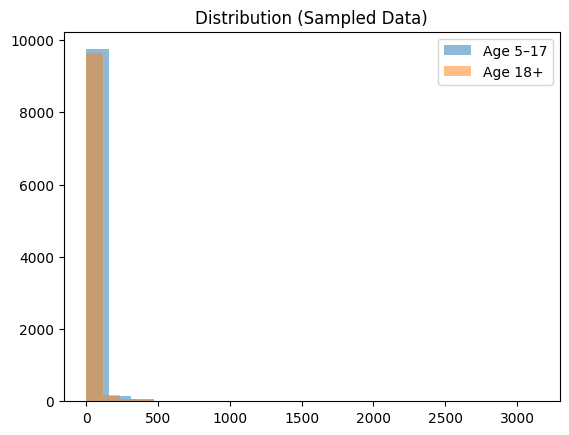

T-statistic: -0.7362
P-value: 0.461629
95% Confidence Interval: (np.float64(-1.9591), np.float64(0.2383))
Cohen's d: -0.0104

Conclusion: No statistically significant difference
Effect Size: Negligible (no practical significance)


In [ ]:
# Subsample the data
sample = bio_df_cleaned[['age_5_17', 'age_18_greater']].dropna().sample(
    n=10000, random_state=42
)

# Descriptive Statistics
mean_5_17 = sample['age_5_17'].mean()
mean_18 = sample['age_18_greater'].mean()

print("Mean (Age 5–17):", round(mean_5_17, 2))
print("Mean (Age 18+):", round(mean_18, 2))
print("Mean Difference:", round(mean_5_17 - mean_18, 4))

# 3. Visual Inspection
plt.hist(sample['age_5_17'], bins=20, alpha=0.5, label='Age 5–17')
plt.hist(sample['age_18_greater'], bins=20, alpha=0.5, label='Age 18+')
plt.legend()
plt.title("Distribution (Sampled Data)")
plt.show()

# 4. Welch’s T-Test
t_stat, p_value = stats.ttest_ind(
    sample['age_5_17'],
    sample['age_18_greater'],
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# 5. Confidence Interval (95%)
diff = sample['age_5_17'] - sample['age_18_greater']

mean_diff = np.mean(diff)
ci_low, ci_high = stats.t.interval(
    0.95,
    len(diff) - 1,
    loc=mean_diff,
    scale=stats.sem(diff)
)

print("95% Confidence Interval:", (round(ci_low, 4), round(ci_high, 4)))

# Effect Size (Cohen’s d)
pooled_std = np.sqrt(
    (sample['age_5_17'].var(ddof=1) + sample['age_18_greater'].var(ddof=1)) / 2
)

cohen_d = mean_diff / pooled_std
print(f"Cohen's d: {cohen_d:.4f}")

# 7. Final Conclusion
alpha = 0.05

if p_value < alpha:
    print("\nConclusion: Statistically significant difference exists")
else:
    print("\nConclusion: No statistically significant difference")

# Practical interpretation
if abs(cohen_d) < 0.2:
    print("Effect Size: Negligible (no practical significance)")
elif abs(cohen_d) < 0.5:
    print("Effect Size: Small")
elif abs(cohen_d) < 0.8:
    print("Effect Size: Medium")
else:
    print("Effect Size: Large")

The analysis compared the mean biometric updates between the age group 5–17 and 18+. The results show that the mean for age 5–17 (19.73) is slightly lower than that for age 18+ (20.59), with a mean difference of -0.86. However, the independent t-test produced a p-value of 0.46, which is greater than the significance level of 0.05. Additionally, the 95% confidence interval (-1.96, 0.24) includes zero, indicating that the difference is not statistically significant. Furthermore, the effect size (Cohen’s d ≈ -0.01) is negligible, suggesting no practical difference between the groups. Therefore, we conclude that there is no meaningful difference in biometric updates between the two age groups.

**Before (Full dataset):**
- p ≈ 0 → “significant”
- BUT effect size ≈ 0

**After (Sampled dataset):**
- p = 0.46 → “not significant”
- Effect size ≈ 0

**BOTH now agree:**
- There is no real difference

# **Is there a significant difference in mean enrolment between North and South regions?**

**Null Hypothesis (H₀)**

- There is no significant difference in mean enrolment between North and South regions.
- $\mu_{\text{North}} = \mu_{\text{South}}$

	​
**Alternative Hypothesis (H₁)**
- There is a significant difference in mean enrolment between North and South regions.
- $\mu_{\text{North}} \neq \mu_{\text{South}}$


In [ ]:
from scipy.stats import ttest_ind

# Extract data for both regions
north_data = enrol_df_cleaned[enrol_df_cleaned['region'] == 'North']['total_enrolment'].values
south_data = enrol_df_cleaned[enrol_df_cleaned['region'] == 'South']['total_enrolment'].values

# Independent T-Test
t_stat, p_value = ttest_ind(north_data, south_data)

# Basic statistics
print(f"\n{'North Region:':<30} n={len(north_data):,}, mean={north_data.mean():.2f}, std={north_data.std():.2f}")
print(f"{'South Region:':<30} n={len(south_data):,}, mean={south_data.mean():.2f}, std={south_data.std():.2f}")

# Results
print("\n----- T-TEST RESULT -----")

print(f"{'Test Statistic (t):':<30} {t_stat:.4f}")
print(f"{'P-Value:':<30} {p_value:.4e}")
print(f"{'Degrees of Freedom:':<30} {len(north_data) + len(south_data) - 2}")

# STEP 5: Decision based on p-value
if p_value < 0.05:
    print("\nRESULT: SIGNIFICANT DIFFERENCE")
    print("Mean enrolment differs between North and South regions")
    print(f"(p-value = {p_value:.4e} < 0.05)")
else:
    print("\nRESULT: NO SIGNIFICANT DIFFERENCE")
    print("No significant difference in mean enrolment")

# Effect Size (Cohen's d)
# formula for Cohen's d
pooled_std = np.sqrt(
    ((len(north_data) - 1) * north_data.std()**2 + (len(south_data) - 1) * south_data.std()**2) / (len(north_data) + len(south_data) - 2))

cohens_d = (north_data.mean() - south_data.mean()) / pooled_std

print(f"\n{'Effect Size (Cohen d):':<30} {cohens_d:.4f}")

# Interpretation of effect size
if abs(cohens_d) < 0.2:
    print("Effect Size: Small")
elif abs(cohens_d) < 0.5:
    print("Effect Size: Medium")
else:
    print("Effect Size: Large")


North Region:                  n=236,827, mean=7.22, std=44.27
South Region:                  n=300,990, mean=2.52, std=8.91

----- T-TEST RESULT -----
Test Statistic (t):            56.7376
P-Value:                       0.0000e+00
Degrees of Freedom:            537815

RESULT: SIGNIFICANT DIFFERENCE
Mean enrolment differs between North and South regions
(p-value = 0.0000e+00 < 0.05)

Effect Size (Cohen d):         0.1558
Effect Size: Small


Although there is a statistically significant difference in enrolment between North and South regions (p < 0.05), the effect size is small (Cohen’s d = 0.1558), indicating that the practical difference between the regions is minimal despite the large sample size.

# **ANOVA**

**Does the state of residence have a statistically significant effect on the proportion of biometric enrollments for the age group 0–5?**

**Null Hypothesis (H₀)**
- There is no significant difference in age (0–5) proportion between states.

**Alternative Hypothesis (H₁)**
- There is a significant difference between at least one pair of states.

In [ ]:
from scipy.stats import f_oneway
import numpy as np

# Create ratio on-the-fly (no new column)
ratio = enrol_df_cleaned['age_0_5'] / enrol_df_cleaned['total_enrolment']

# Clean data (remove NaN / inf)
clean_data = enrol_df_cleaned.copy()
clean_data['ratio'] = ratio
clean_data = clean_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio'])

# Extract data for each state
groups = []
states = clean_data['state'].unique()

for state in states:
    group = clean_data[clean_data['state'] == state]['ratio'].values
    if len(group) > 0:
        groups.append(group)

# ANOVA Test
f_stat, p_value = f_oneway(*groups)

# Results
print("\n----- ANOVA RESULT -----")

print(f"{'F-Statistic:':<30} {f_stat:.4f}")
print(f"{'P-Value:':<30} {p_value:.4e}")
print(f"{'Number of Groups:':<30} {len(groups)}")

# Decision based on p-value
if p_value < 0.05:
    print("\nRESULT: SIGNIFICANT DIFFERENCE")
    print("At least one state has different mean age (0-5 ratio)")
    print(f"(p-value = {p_value:.4e} < 0.05)")
else:
    print("\nRESULT: NO SIGNIFICANT DIFFERENCE")
    print("No significant difference across states")


----- ANOVA RESULT -----
F-Statistic:                   5194.5974
P-Value:                       0.0000e+00
Number of Groups:              36

RESULT: SIGNIFICANT DIFFERENCE
At least one state has different mean age (0-5 ratio)
(p-value = 0.0000e+00 < 0.05)


In [ ]:
import numpy as np
from scipy.stats import f

# Create ratio (no new column stored)
ratio = enrol_df_cleaned['age_0_5'] / enrol_df_cleaned['total_enrolment']

# Extract groups (state-wise)
states = enrol_df_cleaned['state'].unique()
groups = []

for state in states:
    group = ratio[enrol_df_cleaned['state'] == state]
    if len(group) > 0:
        groups.append(group)

# Total number of observations
N = sum(len(g) for g in groups)

# Number of groups
k = len(groups)

# Grand mean
grand_mean = np.mean(np.concatenate(groups))

# Between-group sum of squares (SSB)
SSB = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)

# Within-group sum of squares (SSW)
SSW = sum(sum((g - np.mean(g))**2) for g in groups)

# Degrees of freedom
df_between = k - 1
df_within = N - k

# Mean squares
MSB = SSB / df_between
MSW = SSW / df_within

# F-statistic
F = MSB / MSW

# p-value
p_value = 1 - f.cdf(F, df_between, df_within)

# Results
print("\n----- MANUAL ANOVA RESULT -----")

print(f"{'F-Statistic:':<30} {F:.4f}")
print(f"{'P-Value:':<30} {p_value:.4e}")
print(f"{'DF Between:':<30} {df_between}")
print(f"{'DF Within:':<30} {df_within}")

# Decision
if p_value < 0.05:
    print("\nRESULT: SIGNIFICANT DIFFERENCE")
    print("At least one state has different mean age (0-5 ratio)")
    print(f"(p-value = {p_value:.4e} < 0.05)")
else:
    print("\nRESULT: NO SIGNIFICANT DIFFERENCE")
    print("No significant difference across states")


----- MANUAL ANOVA RESULT -----
F-Statistic:                   5194.5974
P-Value:                       1.1102e-16
DF Between:                    35
DF Within:                     974630

RESULT: SIGNIFICANT DIFFERENCE
At least one state has different mean age (0-5 ratio)
(p-value = 1.1102e-16 < 0.05)


The one-way ANOVA test was conducted to compare the proportion of children aged 0–5 across different states. The results show that the F-statistic is 5194.5974 with a p-value of 1.1102e-16, which is significantly less than the threshold value of 0.05. Therefore, the null hypothesis is rejected.

This indicates that there is a statistically significant difference in the mean proportion of children aged 0–5 among at least one pair of states. Hence, further post-hoc analysis (Tukey HSD) is recommended to identify which specific states differ from each other.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create ratio
ratio = enrol_df_cleaned['age_0_5'] / enrol_df_cleaned['total_enrolment']

# Tukey HSD Test
tukey = pairwise_tukeyhsd(
    endog=ratio,
    groups=enrol_df_cleaned['state'],
    alpha=0.05
)

# Results
print("\n----- TUKEY HSD RESULT -----")
print(tukey)


----- TUKEY HSD RESULT -----
                                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                                   
                 group1                                   group2                  meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------------------------------------
             Andaman And Nicobar Islands                           Andhra Pradesh  -0.0528 0.3851 -0.1182  0.0125  False
             Andaman And Nicobar Islands                        Arunachal Pradesh  -0.4282    0.0 -0.5004  -0.356   True
             Andaman And Nicobar Islands                                    Assam  -0.2868    0.0 -0.3523 -0.2213   True
             Andaman And Nicobar Islands                                    Bihar  -0.4976    0.0 -0.5629 -0.4322   True
             Andaman And Nicobar Islands                               Chandigarh  -0.0241    1.0  -0.102  0.0537  False
  

The results indicate high regional variation, especially involving states like Bihar, Meghalaya, Nagaland, and Arunachal Pradesh, which frequently show significant differences when compared to other states.

**Conclusion (Tukey HSD Test)**

The Tukey HSD post-hoc analysis reveals that a large number of state pairs show statistically significant differences in the proportion of children aged 0–5, as indicated by the “reject = True” results.

Only a few state pairs show no significant difference (reject = False), indicating similar proportions between those states. However, the majority of comparisons are significant, confirming that the variation observed in the ANOVA test is due to real differences across states.

Therefore, it can be concluded that the proportion of children aged 0–5 varies significantly across different states, with some states showing notably higher or lower values compared to others.

# **Top 5 District Comparison**
- In terms of number of people enroled

In [ ]:
# Top 5 data
enrol_top = enrol_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=False).head()

demo_top = demo_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=False).head()

bio_top = bio_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=False).head()

# Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Enrolment Top 5', 'Demo Top 5', 'Bio Top 5')
)

# Enrol
fig.add_trace(
    go.Bar(
        x=enrol_top.index,
        y=enrol_top.values,
        text=enrol_top.values,
        textposition='outside',
        name='Enrol'
    ),
    row=1, col=1
)

# Demo
fig.add_trace(
    go.Bar(
        x=demo_top.index,
        y=demo_top.values,
        text=demo_top.values,
        textposition='outside',
        name='Demo'
    ),
    row=1, col=2
)

# Bio
fig.add_trace(
    go.Bar(
        x=bio_top.index,
        y=bio_top.values,
        text=bio_top.values,
        textposition='outside',
        name='Bio'
    ),
    row=1, col=3
)

# Layout
fig.update_layout(
    title='Top 5 Districts Comparison (Enrol vs Demo vs Bio)',
    showlegend=False,
    height=550
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=90)

# Prevent text cutoff
fig.update_traces(cliponaxis=False)

fig.show()

The plot compares the top 5 districts across enrolment, demographic updates, and biometric updates. It reveals that districts leading in enrolment (e.g., West and East Champaran) do not appear among the top districts for updates, indicating that enrolment and update activities are driven by different factors.
Urban districts such as Pune, Thane, and Bengaluru dominate both demographic and biometric updates, reflecting higher awareness, better infrastructure, and increased Aadhaar usage. In contrast, rural and semi-urban districts show higher enrolment activity.
This highlights a clear rural–urban divide, where rural regions are enrolment-heavy while urban regions are update-heavy. Additionally, districts like Thane and Pune emerge as high-load operational hubs, contributing significantly across multiple datasets.


Key Insight:

The comparison reveals a clear divergence between enrolment-heavy and update-heavy districts, indicating that Aadhaar service utilization varies significantly across geographic and socio-economic contexts.

The Top 5 district comparison highlights a dual-pattern system where rural districts dominate enrolment while urban districts drive update activities, emphasizing the need for region-specific infrastructure and policy planning. This divergence suggests that Aadhaar usage transitions from enrolment-driven in rural areas to maintenance-driven in urban regions.

4. Rural vs Urban Divide
Enrolment leaders:
Champaran, Sitamarhi, Bahraich → more rural/semi-urban
Update leaders:
Pune, Bengaluru, Thane → urban

Indicates:

Rural → enrolment-heavy
Urban → update-heavy

Insight

Aadhaar activity is not uniformly distributed across districts; while rural districts contribute significantly to enrolment, urban districts dominate update activities, highlighting a structural divide in service utilization.

Operational Insight

Aadhaar system workload is bifurcated:

Enrolment load → distributed across rural population centers
Update load → concentrated in urban hubs

Key Finding:

The comparison reveals a clear divergence between enrolment-heavy and update-heavy districts, indicating that Aadhaar service utilization varies significantly across geographic and socio-economic contexts.

The Top 5 district comparison highlights a dual-pattern system where rural districts dominate enrolment while urban districts drive update activities, emphasizing the need for region-specific infrastructure and policy planning.
This divergence suggests that Aadhaar usage transitions from enrolment-driven in rural areas to maintenance-driven in urban regions.

# **Bottom 5 District Comparison**
- In terms of number of people enroled

In [ ]:
# Bottom 5 data
enrol_bottom = enrol_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=True).head()

demo_bottom = demo_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=True).head()

bio_bottom = bio_df_cleaned.groupby('district')['total_enrolment'].sum().sort_values(ascending=True).head()

# Create subplots
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Enrolment Bottom 5', 'Demo Bottom 5', 'Bio Bottom 5')
)

# Enrol
fig.add_trace(
    go.Bar(
        x=enrol_bottom.index,
        y=enrol_bottom.values,
        text=enrol_bottom.values,
        textposition='outside',
        name='Enrol'
    ),
    row=1, col=1
)

# Demo
fig.add_trace(
    go.Bar(
        x=demo_bottom.index,
        y=demo_bottom.values,
        text=demo_bottom.values,
        textposition='outside',
        name='Demo'
    ),
    row=1, col=2
)

# Bio
fig.add_trace(
    go.Bar(
        x=bio_bottom.index,
        y=bio_bottom.values,
        text=bio_bottom.values,
        textposition='outside',
        name='Bio'
    ),
    row=1, col=3
)

# Layout
fig.update_layout(
    title='Bottom 5 Districts Comparison (Enrol vs Demo vs Bio)',
    showlegend=False,
    height=550
)

# Rotate x labels
fig.update_xaxes(tickangle=90)

# Prevent label cutoff
fig.update_traces(cliponaxis=False)

fig.show()

The plot compares the bottom 5 districts across enrolment, demographic updates, and biometric updates. It shows that several districts consistently record extremely low activity across all three datasets, with enrolment values as low as 1 and similarly minimal counts in demographic and biometric updates.

This indicates the presence of low-activity or underrepresented regions, which may be due to factors such as low population density, limited infrastructure, geographical constraints, or reduced access to Aadhaar services.

Additionally, some districts appear across multiple bottom categories, highlighting persistently low engagement in Aadhaar-related activities.

🔹 Key Insight

The existence of consistently low-performing districts highlights regional disparities and potential service accessibility gaps, emphasizing the need for targeted interventions to improve Aadhaar penetration and update activity in these areas.

# **Selected State Insight**

In [ ]:
def generate_state_insights(df, state_col='state', date_col='date', value_col='total_enrolment', state_list=None):
    """
    Generate full analytical insights from enrolment-like dataset.

    Parameters:
    - df : pandas DataFrame
    - state_col : column name for state/category
    - date_col : column name for date
    - value_col : column name for metric (e.g., enrolment)
    - state_list : optional list to filter states

    Returns:
    - Prints insights
    """

    data = df.copy()

    # Filter states if provided
    if state_list:
        data = data[data[state_col].isin(state_list)]

    # Ensure datetime
    data[date_col] = pd.to_datetime(data[date_col])

    # --- Aggregations ---
    state_total = data.groupby(state_col)[value_col].sum()
    state_mean = data.groupby(state_col)[value_col].mean()
    state_std = data.groupby(state_col)[value_col].std()
    state_max = data.groupby(state_col)[value_col].max()
    state_min = data.groupby(state_col)[value_col].min()

    daily = data.groupby(date_col)[value_col].sum()

    # --- Growth ---
    growth_total = ((daily.iloc[-1] - daily.iloc[0]) / max(daily.iloc[0], 1)) * 100

    state_growth = data.sort_values(date_col).groupby(state_col).apply(
        lambda x: ((x[value_col].iloc[-1] - x[value_col].iloc[0]) /
                   max(x[value_col].iloc[0], 1)) * 100
    )

    # --- Trend (slope) ---
    trend = data.groupby(state_col).apply(
        lambda x: np.polyfit(range(len(x)), x[value_col], 1)[0] if len(x) > 1 else 0
    )

    # --- OUTPUT ---
    print("\n🏆 TOP PERFORMANCE")
    print(f"🏆 Highest total: {state_total.idxmax()}")
    print(f"🥇 Highest average: {state_mean.idxmax()}")
    print(f"📊 Highest single-day: {state_max.idxmax()} ({state_max.max():.0f})")

    print("\n⚠️ LOW PERFORMANCE")
    print(f"📉 Lowest total: {state_total.idxmin()}")
    print(f"🐢 Lowest average: {state_mean.idxmin()}")
    print(f"🔻 Lowest single-day: {state_min.idxmin()} ({state_min.min():.0f})")

    print("\n📈 GROWTH")
    print(f"📈 Overall growth: {growth_total:.2f}%")
    print(f"🚀 Fastest growing: {state_growth.idxmax()} ({state_growth.max():.2f}%)")
    print(f"🐌 Slowest growing: {state_growth.idxmin()} ({state_growth.min():.2f}%)")

    print("\n📊 STABILITY")
    print(f"🎯 Most consistent: {state_std.idxmin()}")
    print(f"⚡ Most volatile: {state_std.idxmax()}")

    print("\n📅 TIME INSIGHTS")
    print(f"📅 Peak day: {daily.idxmax().date()} ({daily.max():.0f})")
    print(f"📉 Lowest day: {daily.idxmin().date()} ({daily.min():.0f})")

    print("\n📉 TREND")
    print(f"📈 Strongest upward trend: {trend.idxmax()}")
    print(f"📉 Weakest trend: {trend.idxmin()}")

    print("\n🏁 RANKINGS")
    print("\n🔝 Total Ranking:")
    print(state_total.sort_values(ascending=False))

    print("\n📊 Average Ranking:")
    print(state_mean.sort_values(ascending=False))

    print("\n📈 Growth Ranking:")
    print(state_growth.sort_values(ascending=False))

    print("\n📊 Contribution (%)")
    contribution = (state_total / state_total.sum()) * 100
    print(contribution.sort_values(ascending=False))

In [ ]:
north_east = ['Arunachal Pradesh', 'Assam' , 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Tripura']

In [ ]:
generate_state_insights(enrol_df_cleaned, state_list= north_east)


🏆 TOP PERFORMANCE
🏆 Highest total: Assam
🥇 Highest average: Meghalaya
📊 Highest single-day: Meghalaya (3027)

⚠️ LOW PERFORMANCE
📉 Lowest total: Arunachal Pradesh
🐢 Lowest average: Arunachal Pradesh
🔻 Lowest single-day: Arunachal Pradesh (1)

📈 GROWTH
📈 Overall growth: 2819.27%
🚀 Fastest growing: Meghalaya (-86.24%)
🐌 Slowest growing: Nagaland (-99.73%)

📊 STABILITY
🎯 Most consistent: Tripura
⚡ Most volatile: Meghalaya

📅 TIME INSIGHTS
📅 Peak day: 2025-07-01 (79601)
📉 Lowest day: 2025-11-04 (25)

📉 TREND
📈 Strongest upward trend: Tripura
📉 Weakest trend: Meghalaya

🏁 RANKINGS

🔝 Total Ranking:
state
Assam                225355
Meghalaya            109239
Nagaland              15429
Manipur               13199
Tripura               11006
Mizoram                5774
Arunachal Pradesh      4240
Name: total_enrolment, dtype: int64

📊 Average Ranking:
state
Meghalaya            29.700653
Nagaland              7.908252
Assam                 7.341749
Manipur               4.196820
Mizoram   

/tmp/ipykernel_8939/3079281684.py:37: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_8939/3079281684.py:43: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
generate_state_insights(demo_df_cleaned, state_list= north_east)


🏆 TOP PERFORMANCE
🏆 Highest total: Assam
🥇 Highest average: Manipur
📊 Highest single-day: Assam (2752)

⚠️ LOW PERFORMANCE
📉 Lowest total: Nagaland
🐢 Lowest average: Arunachal Pradesh
🔻 Lowest single-day: Arunachal Pradesh (0)

📈 GROWTH
📈 Overall growth: -95.35%
🚀 Fastest growing: Tripura (-91.83%)
🐌 Slowest growing: Arunachal Pradesh (-99.57%)

📊 STABILITY
🎯 Most consistent: Arunachal Pradesh
⚡ Most volatile: Manipur

📅 TIME INSIGHTS
📅 Peak day: 2025-03-01 (253548)
📉 Lowest day: 2025-10-22 (505)

📉 TREND
📈 Strongest upward trend: Assam
📉 Weakest trend: Meghalaya

🏁 RANKINGS

🔝 Total Ranking:
state
Assam                755090
Manipur              233382
Tripura              104568
Meghalaya             63941
Mizoram               31556
Arunachal Pradesh     28391
Nagaland              27555
Name: total_enrolment, dtype: int64

📊 Average Ranking:
state
Manipur              40.630571
Assam                15.929833
Meghalaya            15.296890
Tripura              15.019822
Mizoram    

/tmp/ipykernel_8939/3079281684.py:37: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_8939/3079281684.py:43: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
generate_state_insights(bio_df_cleaned, state_list= north_east)


🏆 TOP PERFORMANCE
🏆 Highest total: Assam
🥇 Highest average: Manipur
📊 Highest single-day: Manipur (5299)

⚠️ LOW PERFORMANCE
📉 Lowest total: Arunachal Pradesh
🐢 Lowest average: Arunachal Pradesh
🔻 Lowest single-day: Assam (0)

📈 GROWTH
📈 Overall growth: -96.52%
🚀 Fastest growing: Assam (-80.00%)
🐌 Slowest growing: Meghalaya (-99.54%)

📊 STABILITY
🎯 Most consistent: Arunachal Pradesh
⚡ Most volatile: Manipur

📅 TIME INSIGHTS
📅 Peak day: 2025-04-01 (263485)
📉 Lowest day: 2025-12-22 (1)

📉 TREND
📈 Strongest upward trend: Assam
📉 Weakest trend: Mizoram

🏁 RANKINGS

🔝 Total Ranking:
state
Assam                945150
Tripura              285321
Manipur              275900
Mizoram              119160
Nagaland             108271
Meghalaya             86574
Arunachal Pradesh     70059
Name: total_enrolment, dtype: int64

📊 Average Ranking:
state
Manipur              44.129878
Mizoram              37.040721
Tripura              35.898465
Nagaland             29.533824
Meghalaya            21.55

/tmp/ipykernel_8939/3079281684.py:37: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_8939/3079281684.py:43: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
def generate_subplot_dashboard(df, state_col='state', date_col='date', value_col='total_enrolment', state_list=None):

    data = df.copy()

    # Filter states
    if state_list:
        data = data[data[state_col].isin(state_list)]

    data[date_col] = pd.to_datetime(data[date_col])

    # Aggregations
    state_total = data.groupby(state_col)[value_col].sum().sort_values(ascending=False)
    state_std = data.groupby(state_col)[value_col].std().sort_values(ascending=False)
    daily = data.groupby(date_col)[value_col].sum()

    state_growth = (
        data.sort_values(date_col).groupby(state_col)[value_col].apply(lambda x: ((x.iloc[-1] - x.iloc[0]) / max(x.iloc[0], 1)) * 100).sort_values(ascending=False)
    )

    contribution = (state_total / state_total.sum()) * 100
    trend_df = data.groupby([date_col, state_col])[value_col].sum().reset_index()

    # Color Mapping
    states = sorted(data[state_col].unique())
    colors = px.colors.qualitative.Plotly

    color_map = {
        state: colors[i % len(colors)]
        for i, state in enumerate(states)
    }

    # Subplots Layout
    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=(
            "📈 Trend Over Time",
            "🏆 Total Enrolment",
            "🚀 Growth %",
            "📊 Contribution %",
            "⚡ Volatility (Std Dev)",
            ""
        ),
        specs=[
            [{"colspan": 2}, None],
            [{}, {}],
            [{"type": "domain"}, {}]
        ]
    )

    # Trend Line
    for state in states:
        temp = trend_df[trend_df[state_col] == state]
        fig.add_trace(
            go.Scatter(
                x=temp[date_col],
                y=temp[value_col],
                mode='lines',
                name=state,
                line=dict(color=color_map[state])
            ),
            row=1, col=1
        )

    # Total Enrolment
    fig.add_trace(
        go.Bar(
            x=state_total.index,
            y=state_total.values,
            text=state_total.values,
            textposition='outside',
            marker_color=[color_map[s] for s in state_total.index],
            name='Total'
        ),
        row=2, col=1
    )

    # Growth %
    fig.add_trace(
        go.Bar(
            x=state_growth.index,
            y=state_growth.values,
            text=[f"{v:.1f}%" for v in state_growth.values],
            textposition='outside',
            marker_color=[color_map[s] for s in state_growth.index],
            name='Growth'
        ),
        row=2, col=2
    )

    # Contribution Pie
    fig.add_trace(
        go.Pie(
            labels=contribution.index,
            values=contribution.values,
            marker=dict(colors=[color_map[s] for s in contribution.index]),
            name="Contribution"
        ),
        row=3, col=1
    )

    # Volatility (Std Dev)
    fig.add_trace(
    go.Scatter(
        x=state_std.index,
        y=state_std.values,
        fill='tozeroy',
        mode='lines+markers+text',
        text=[f"{v:.0f}" for v in state_std.values],
        textposition='top center',
        line=dict(color='royalblue'),
        name='Volatility'
    ),
    row=3, col=2
    )

    # Layout Settings
    fig.update_layout(
        height=900,
        showlegend=True
    )

    fig.update_xaxes(tickangle=45)

    # Apply only to bar charts
    fig.update_traces(cliponaxis=False, selector=dict(type='bar'))

    fig.show()

In [ ]:
generate_subplot_dashboard(enrol_df_cleaned, state_list=north_east)

🔹 Key Observations
1. Trend Over Time
The time-series plot shows that enrolment activity peaked around mid-2025, followed by a sharp decline and relatively low activity thereafter. Assam and Meghalaya exhibit the highest peaks, while other states maintain comparatively lower trends.
Interpretation:
•	Aadhaar activity is event-driven rather than continuous
•	Mid-year spikes may correspond to enrolment drives or administrative campaigns
2. Total Enrolment Distribution
Assam dominates total enrolment (~225K), followed by Meghalaya (~109K), while other states contribute significantly less.
Interpretation:
•	Strong centralization of enrolment activity
•	Reflects population and infrastructure imbalance
3. Growth Percentage
All states exhibit negative growth rates, with steep declines observed across the region.
Interpretation:
•	Indicates declining enrolment trend over time
•	Suggests possible saturation of Aadhaar enrolment
4. Contribution Share
The pie chart shows Assam contributing nearly 58.6% of total activity, followed by Meghalaya (~28.4%), with remaining states contributing minimal shares.
Interpretation:
•	High dependency on a single state
•	Regional imbalance is clearly visible
5. Volatility Analysis
Meghalaya shows the highest volatility, while states like Tripura and Arunachal Pradesh exhibit low variability.
Interpretation:
•	High volatility → inconsistent activity (spikes and drops)
•	Low volatility → stable but low activity levels
🔹 Key Insight
Aadhaar activity in the North-East region is highly concentrated, temporally inconsistent, and declining over time, with Assam acting as the dominant contributor while other states remain underrepresented.
🔹 Analytical Finding
The combined analysis of trends, growth, contribution, and volatility confirms that Aadhaar operations in the North-East are uneven, event-driven, and increasingly saturated, highlighting the need for balanced regional development and sustained engagement strategies.


In [ ]:
generate_subplot_dashboard(demo_df_cleaned, state_list=north_east)

Key Observations
1. Trend Over Time
The time-series plot shows a very high spike at the beginning of the year, followed by a sharp decline and relatively low, fluctuating activity thereafter. Assam dominates the trend initially, while other states maintain comparatively lower and stable patterns.
Interpretation:
•	Demographic updates are highly event-driven
•	Initial spike may indicate bulk updates or data backlog processing
2. Total Demographic Updates
Assam leads significantly (~755K), followed by Manipur (~233K) and Tripura (~104K), while other states contribute relatively smaller volumes.
Interpretation:
•	Assam acts as the primary update hub
•	Manipur shows strong secondary participation

3. Growth Percentage
All states show negative growth rates, indicating a consistent decline in update activity over time.
Interpretation:
•	Suggests:
o	Reduced update demand
o	Possible stabilization after initial bulk updates
4. Contribution Share
Assam contributes approximately 60.7% of total demographic updates, followed by Manipur (~18.8%) and Tripura (~8.4%), with remaining states contributing minimal shares.
Interpretation:
•	Strong centralization of update activity
•	Significant regional imbalance persists
5. Volatility Analysis
Manipur and Meghalaya show higher volatility, while Arunachal Pradesh and Nagaland exhibit relatively lower variability.
Interpretation:
•	High volatility → irregular update patterns
•	Low volatility → consistently low activity
🔹 Key Insight
Demographic update activity in the North-East region is highly centralized, declining over time, and influenced by initial high-volume update events, with Assam dominating and other states showing comparatively limited participation.
🔹 Analytical Finding
The demographic dataset highlights that update activity is not uniformly distributed and tends to decrease significantly after initial peaks, indicating that Aadhaar demographic updates are episodic and driven by specific operational or administrative factors.


In [ ]:
generate_subplot_dashboard(bio_df_cleaned, state_list=north_east)

Key Observations
1. Trend Over Time
The time-series plot shows moderate activity in the early months, followed by a noticeable spike around mid-year (especially for Assam and Manipur), and a sharp decline thereafter with minimal fluctuations.
Interpretation:
•	Biometric updates are event-driven and periodic
•	Mid-year spike likely corresponds to:
o	Revalidation cycles
o	Policy-driven update campaigns
2. Total Biometric Updates
Assam leads significantly (~945K), followed by Tripura (~285K) and Manipur (~275K), while other states contribute smaller shares.
Interpretation:
•	Assam remains the dominant contributor
•	Tripura and Manipur play strong secondary roles
3. Growth Percentage
All states show negative growth, though Assam and Mizoram show relatively less decline compared to others.
Interpretation:
•	Indicates:
o	Decreasing update activity over time
o	Possible completion of major biometric update cycles
4. Contribution Share
Assam contributes around 50% of total biometric updates, followed by Tripura (~15%) and Manipur (~14.6%), with other states contributing smaller portions.
Interpretation:
•	Activity is highly centralized
•	Strong dependency on few states
5. Volatility Analysis
Manipur and Mizoram exhibit the highest volatility, while Arunachal Pradesh and Assam show relatively lower variability.
Interpretation:
•	High volatility → irregular and burst-like updates
•	Low volatility → steady but limited activity
🔹 Key Insight
Biometric update activity in the North-East region is concentrated in a few states, shows strong mid-cycle spikes, and declines over time, indicating that updates are periodic and driven by lifecycle or regulatory requirements.
🔹 Analytical Finding
The biometric dataset confirms that Aadhaar updates are not continuous but occur in bursts, with significant regional concentration and declining trends, reflecting completion of update cycles and uneven infrastructure distribution.


## **Monthly Trend**

In [ ]:
def plot_monthly_trend(df, title):
    monthly = (
        df.set_index('date')['total_enrolment']
        .resample('ME')
        .sum()
        .reset_index()
    )

    monthly['Smoothed'] = monthly['total_enrolment'].rolling(3).mean()

    px.line(
        monthly,
        x='date',
        y=['total_enrolment', 'Smoothed'],
        title=title
    ).show()

In [ ]:
plot_monthly_trend(enrol_df_cleaned, "Monthly Enrolment Trend")

- Phase 1: Low activity (Mar–Jul)
- Phase 2: Break (Aug)
- Phase 3: High activity (Sep–Dec)

In [ ]:
plot_monthly_trend(demo_df_cleaned, "Monthly Demographic Trend")

- Phase 1: High spike (Mar)
- Phase 2: Low stable (Apr–Jul)
- Phase 3: Break (Aug)
- Phase 4: High steady (Sep–Dec)

In [ ]:
plot_monthly_trend(bio_df_cleaned, "Monthly Biometric Trend")

- Phase 1: High stable (Mar–Jul)
- Phase 2: Break / crash (Aug)
- Phase 3: Partial recovery (Sep–Oct)
- Phase 4: Rising steady (Nov–Dec)

## **States have skewed age distributions**

In [ ]:
def get_skewed_age_states(df, threshold=0.5):
    age_distribution = df.groupby('state')[
        ['age_0_5', 'age_5_17', 'age_18_greater']
    ].sum()

    # Coefficient of Variation
    age_distribution['cv'] = (
        age_distribution.std(axis=1) / age_distribution.mean(axis=1)
    )

    # Filter skewed states
    skewed_states = (
        age_distribution[age_distribution['cv'] > threshold]
        .sort_values('cv', ascending=False)
    )

    return skewed_states

In [ ]:
get_skewed_age_states(enrol_df_cleaned)

,age_0_5,age_5_17,age_18_greater,cv
state,,,,
Himachal Pradesh,16077,650,178,1.605344
Lakshadweep,188,10,1,1.589887
Andaman And Nicobar Islands,439,32,0,1.558871
Puducherry,2533,190,44,1.514406
Chandigarh,2377,210,33,1.494524
Haryana,85111,8896,1076,1.464777
Andhra Pradesh,108217,13396,1465,1.425781
Uttarakhand,31194,5410,338,1.343679
Dadra And Nagar Haveli And Daman And Diu,1464,248,50,1.303592


States with a high coefficient of variation (CV > 0.5) show a skewed age distribution, where one age group significantly outweighs others. This may indicate demographic imbalance or data collection bias in those states.

## **State-wise Age Group Dominance and Share**

In [ ]:
def get_dominant_age_group(df):
    expected_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

    age_cols = [col for col in expected_cols if col in df.columns]

    df_copy = df.copy()

    for col in age_cols:
        df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')

    df_copy[age_cols] = df_copy[age_cols].fillna(0)

    age_distribution = df_copy.groupby('state')[age_cols].sum()

    result = pd.DataFrame()
    result['dominant_age_group'] = age_distribution.idxmax(axis=1)
    result['dominant_share'] = (
        age_distribution.max(axis=1) /
        age_distribution.sum(axis=1)
    )

    result = result.reset_index()

    return result.sort_values('dominant_share', ascending=False)

In [ ]:
def plot_dominant_age(df):
    data = get_dominant_age_group(df).sort_values('dominant_share', ascending=True)

    fig = px.bar(
        data,
        x='dominant_share',
        y='state',
        color='dominant_age_group',
        orientation='h',
        title='Dominant Age Group by State'
    )

    fig.show()

In [ ]:
get_dominant_age_group(enrol_df_cleaned)

,state,dominant_age_group,dominant_share
12,Himachal Pradesh,age_0_5,0.951020
18,Lakshadweep,age_0_5,0.944724
0,Andaman And Nicobar Islands,age_0_5,0.932059
26,Puducherry,age_0_5,0.915432
5,Chandigarh,age_0_5,0.907252
11,Haryana,age_0_5,0.895123
1,Andhra Pradesh,age_0_5,0.879255
34,Uttarakhand,age_0_5,0.844405
7,Dadra And Nagar Haveli And Daman And Diu,age_0_5,0.830874
30,Tamil Nadu,age_0_5,0.825950


In [ ]:
plot_dominant_age(enrol_df_cleaned)

In [ ]:
get_dominant_age_group(demo_df_cleaned)

,state,dominant_age_group,dominant_share
20,Maharashtra,age_18_greater,0.946586
35,West Bengal,age_18_greater,0.937639
27,Punjab,age_18_greater,0.936438
14,Jharkhand,age_18_greater,0.928184
4,Bihar,age_18_greater,0.921436
16,Kerala,age_18_greater,0.918095
6,Chhattisgarh,age_18_greater,0.917124
3,Assam,age_18_greater,0.916605
32,Tripura,age_18_greater,0.913176
0,Andaman And Nicobar Islands,age_18_greater,0.908985


In [ ]:
plot_dominant_age(demo_df_cleaned)

In [ ]:
get_dominant_age_group(bio_df_cleaned)

,state,dominant_age_group,dominant_share
23,Mizoram,age_5_17,0.711195
24,Nagaland,age_18_greater,0.704399
6,Chhattisgarh,age_18_greater,0.671997
5,Chandigarh,age_5_17,0.661940
29,Sikkim,age_5_17,0.657607
33,Uttar Pradesh,age_5_17,0.648701
20,Maharashtra,age_18_greater,0.618975
26,Puducherry,age_18_greater,0.612762
3,Assam,age_5_17,0.607423
1,Andhra Pradesh,age_5_17,0.604290


In [ ]:
plot_dominant_age(bio_df_cleaned)

### **Disparity score for each region**

In [ ]:
regional_stats = enrol_df_cleaned.groupby('region').agg({
    'total_enrolment': ['sum', 'mean', 'std', 'count']
}).round(2)

regional_stats.columns = ['Total', 'Mean', 'Std Dev', 'Records']
regional_stats['Coefficient_of_Variation'] = (
    regional_stats['Std Dev'] / regional_stats['Mean']
)

print("Regional Disparity Index:")
display(regional_stats.sort_values('Coefficient_of_Variation', ascending=False))

Regional Disparity Index:


,Total,Mean,Std Dev,Records,Coefficient_of_Variation
region,,,,,
North,1709568,7.22,44.27,236827,6.131579
West,642304,5.25,32.01,122457,6.097143
North-East,384242,8.34,49.21,46097,5.900480
East,1235717,6.15,29.50,200892,4.796748
Central,587444,8.72,38.09,67403,4.368119
South,759716,2.52,8.91,300990,3.535714


/tmp/ipykernel_8939/2207002607.py:34: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



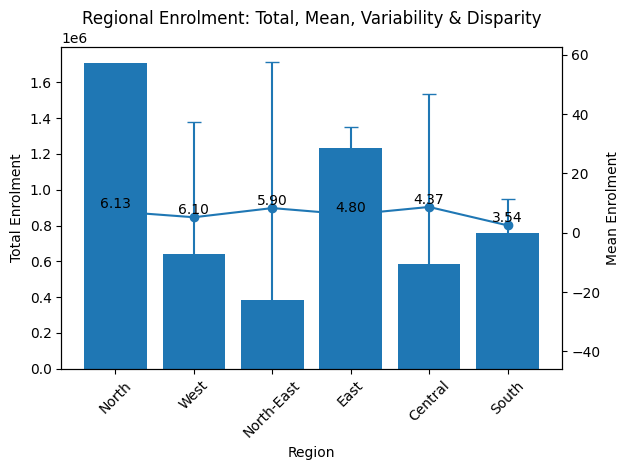

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

regional_stats_sorted = regional_stats.sort_values('Coefficient_of_Variation', ascending=False)

regions = regional_stats_sorted.index
x = np.arange(len(regions))

fig, ax1 = plt.subplots()

# --- Bar plot: Total Enrolment ---
ax1.bar(x, regional_stats_sorted['Total'])
ax1.set_xlabel('Region')
ax1.set_ylabel('Total Enrolment')
ax1.set_xticks(x)
ax1.set_xticklabels(regions, rotation=45)

# --- Line plot: Mean Enrolment ---
ax2 = ax1.twinx()
ax2.plot(x, regional_stats_sorted['Mean'], marker='o')
ax2.set_ylabel('Mean Enrolment')

# --- Error bars: Std Dev ---
ax2.errorbar(
    x,
    regional_stats_sorted['Mean'],
    yerr=regional_stats_sorted['Std Dev'],
    fmt='none',
    capsize=5
)

# --- Annotate CV values ---
for i, cv in enumerate(regional_stats_sorted['Coefficient_of_Variation']):
    ax2.text(x[i], regional_stats_sorted['Mean'][i], f"{cv:.2f}", ha='center', va='bottom')

plt.title('Regional Enrolment: Total, Mean, Variability & Disparity')
plt.tight_layout()
plt.show()

In [ ]:
def auto_generate_insights(df):
    insights = []

    df_copy = df.copy()

    # --- Top performer ---
    state_totals = df_copy.groupby('state')['total_enrolment'].sum()
    top_state = state_totals.idxmax()
    insights.append(f"🏆 Highest enrolment state: {top_state}")

    # --- Low performers ---
    low_states = df_copy.groupby('state')['total_enrolment'].mean().nsmallest(3)
    insights.append(f"⚠️ Low enrolment states: {', '.join(low_states.index)}")

    # --- Growth ---
    df_sorted = df_copy.sort_values('date')
    daily_totals = df_sorted.groupby('date')['total_enrolment'].sum()

    first_day = daily_totals.iloc[0]
    last_day = daily_totals.iloc[-1]

    if first_day != 0:
        growth = ((last_day - first_day) / first_day) * 100
        insights.append(f"📈 Overall growth: {growth:.2f}%")
    else:
        insights.append("📈 Growth cannot be calculated (initial value is 0)")

    # --- Peak day ---
    peak_date = daily_totals.idxmax()
    peak_value = daily_totals.max()
    insights.append(f"📅 Peak enrolment day: {peak_date.date()} ({int(peak_value)})")

    # --- Most consistent state (low variation) ---
    state_std = df_copy.groupby('state')['total_enrolment'].std()
    consistent_state = state_std.idxmin()
    insights.append(f"🎯 Most consistent state: {consistent_state}")

    # --- Most volatile state ---
    volatile_state = state_std.idxmax()
    insights.append(f"⚡ Most volatile state: {volatile_state}")

    # --- Fastest growing state ---
    growth_by_state = df_copy.sort_values('date').groupby('state')['total_enrolment'].agg(['first', 'last'])
    growth_by_state['growth_%'] = (
        (growth_by_state['last'] - growth_by_state['first']) /
        growth_by_state['first'].replace(0, 1)
    ) * 100

    fastest_state = growth_by_state['growth_%'].idxmax()
    insights.append(f"🚀 Fastest growing state: {fastest_state}")


    return "\n".join(insights)

In [ ]:
print(auto_generate_insights(enrol_df_cleaned))

🏆 Highest enrolment state: Uttar Pradesh
⚠️ Low enrolment states: Lakshadweep, Andaman And Nicobar Islands, Goa
📈 Overall growth: 109082.57%
📅 Peak enrolment day: 2025-07-01 (616868)
🎯 Most consistent state: Lakshadweep
⚡ Most volatile state: Meghalaya
🚀 Fastest growing state: Puducherry


In [ ]:
print(auto_generate_insights(demo_df_cleaned))

🏆 Highest enrolment state: Uttar Pradesh
⚠️ Low enrolment states: Lakshadweep, Andaman And Nicobar Islands, Sikkim
📈 Overall growth: -96.94%
📅 Peak enrolment day: 2025-03-01 (8185002)
🎯 Most consistent state: Lakshadweep
⚡ Most volatile state: Delhi
🚀 Fastest growing state: Lakshadweep


In [ ]:
print(auto_generate_insights(bio_df_cleaned))

🏆 Highest enrolment state: Uttar Pradesh
⚠️ Low enrolment states: Ladakh, Lakshadweep, Sikkim
📈 Overall growth: -96.56%
📅 Peak enrolment day: 2025-07-01 (9785768)
🎯 Most consistent state: Ladakh
⚡ Most volatile state: Delhi
🚀 Fastest growing state: Arunachal Pradesh


In [ ]:
import inspect

def list_user_functions():
    functions = []
    for name, obj in globals().items():
        if inspect.isfunction(obj) and obj.__module__ == "__main__":
            functions.append(name)
    return sorted(functions)

list_user_functions()

['add_age_ratios',
 'age_group_stats_by_state',
 'auto_generate_insights',
 'box_plot',
 'check_duplicates',
 'check_key_duplicates',
 'clean_district',
 'clean_state_column',
 'column_checker',
 'convert_to_datetime',
 'count_duplicate_rows_per_state',
 'describe_checker',
 'drop_duplicates',
 'dtypes_checker',
 'duplicate_row_percentage',
 'enrolment_stats_by_state',
 'fill_missing_all_median',
 'generate_state_insights',
 'generate_subplot_dashboard',
 'get_dominant_age_group',
 'get_skewed_age_states',
 'get_state_data',
 'head_checker',
 'index_checker',
 'info_checker',
 'isnull_checker',
 'list_user_functions',
 'max_total_enrolment',
 'nunique_checker',
 'outliers_analysis',
 'plot_age_distribution',
 'plot_age_distribution_by_region',
 'plot_check_region_distribution',
 'plot_dominant_age',
 'plot_monthly_trend',
 'rank_state_and_district',
 'remove_null_values',
 'scatter_plot',
 'shape_checker',
 'tail_checker',
 'top_district_by_total_enrolment',
 'top_states_by_total_enrol

In [ ]:
# Grouping by state for the Demographic dataframe as an example
state_comparison = demo_df_cleaned.groupby('state')[['age_5_17', 'age_18_greater']].sum()

# Calculate percentage to normalize for population size
state_comparison['% Adult'] = (state_comparison['age_18_greater'] /
                               (state_comparison['age_18_greater'] + state_comparison['age_5_17'])) * 100

print(state_comparison.sort_values('% Adult', ascending=False))

                                          age_5_17  age_18_greater    % Adult
state                                                                        
Maharashtra                                 204290         3620374  94.658616
West Bengal                                 177238         2664874  93.763863
Punjab                                       40795          601022  93.643827
Jharkhand                                    76496          988665  92.818363
Bihar                                       285883         3352955  92.143563
Kerala                                       46992          526746  91.809502
Chhattisgarh                                117797         1303560  91.712357
Assam                                        62971          692119  91.660464
Tripura                                       9079           95489  91.317612
Andaman And Nicobar Islands                    468            4674  90.898483
Rajasthan                                   189178         18696

## **Is there a statistically significant difference in the mean proportion of 0-5 age group enrolments (% toddlers (0–5)) between Uttar Pradesh and Andaman And Nicobar Islands?**

In [ ]:
from scipy import stats

# Select the two states for comparison
state1 = 'Uttar Pradesh'
state2 = 'Andaman And Nicobar Islands'

# Filter enrol_df for the selected states and the 'age_0_5_ratio'
enrol_ratio_state1 = enrol_df_cleaned[enrol_df_cleaned['state'] == state1]['% toddlers (0–5)']
enrol_ratio_state2 = enrol_df_cleaned[enrol_df_cleaned['state'] == state2]['% toddlers (0–5)']

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(enrol_ratio_state1, enrol_ratio_state2, equal_var=False) # Assuming unequal variances

print(f"Independent t-test for age_0_5_ratio between {state1} and {state2}:")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level (alpha={alpha}), we reject the null hypothesis.")
    print(f"This suggests there is a statistically significant difference in the mean % toddlers (0–5) between {state1} and {state2}.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level (alpha={alpha}), we fail to reject the null hypothesis.")
    print(f"This suggests there is no statistically significant difference in the mean % toddlers (0–5) between {state1} and {state2}.")

print(f"\nMean % toddlers (0–5) for {state1}: {enrol_ratio_state1.mean():.3f}")
print(f"Mean % toddlers (0–5) for {state2}: {enrol_ratio_state2.mean():.3f}")

Independent t-test for age_0_5_ratio between Uttar Pradesh and Andaman And Nicobar Islands:
T-statistic: -35.278
P-value: 0.000

Since the p-value (0.000) is less than the significance level (alpha=0.05), we reject the null hypothesis.
This suggests there is a statistically significant difference in the mean % toddlers (0–5) between Uttar Pradesh and Andaman And Nicobar Islands.

Mean % toddlers (0–5) for Uttar Pradesh: 52.288
Mean % toddlers (0–5) for Andaman And Nicobar Islands: 93.922


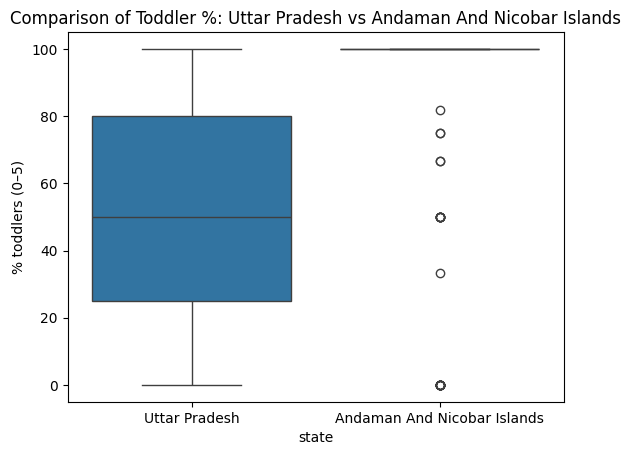

In [ ]:
comparison_df = enrol_df_cleaned[enrol_df_cleaned['state'].isin([state1, state2])]
sns.boxplot(x='state', y='% toddlers (0–5)', data=comparison_df)
plt.title(f'Comparison of Toddler %: {state1} vs {state2}')
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# This will compare every state to every other state and adjust the p-values
tukey = pairwise_tukeyhsd(endog=enrol_df_cleaned['% toddlers (0–5)'],
                          groups=enrol_df_cleaned['state'],
                          alpha=0.05)

print(tukey)

                                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                                    
                 group1                                   group2                  meandiff p-adj   lower    upper   reject
--------------------------------------------------------------------------------------------------------------------------
             Andaman And Nicobar Islands                           Andhra Pradesh  -5.2835 0.3851 -11.8186   1.2515  False
             Andaman And Nicobar Islands                        Arunachal Pradesh -42.8187    0.0   -50.04 -35.5973   True
             Andaman And Nicobar Islands                                    Assam -28.6804    0.0 -35.2346 -22.1262   True
             Andaman And Nicobar Islands                                    Bihar -49.7564    0.0 -56.2928   -43.22   True
             Andaman And Nicobar Islands                               Chandigarh  -2.4144    1.0 -10.2034   5.3746  False
             And

## **Is there a statistically significant difference in the mean proportion of 17-year-old age group (% school-age (5–17)) in demographic updates between Uttar Pradesh and Maharashtra?**

In [ ]:
demo_df_cleaned.columns

Index(['date', 'state', 'district', 'pincode', 'age_5_17', 'age_18_greater',
       'total_enrolment', '% school-age (5–17)', '% adults (18+)', 'region'],
      dtype='object')

In [ ]:
from scipy import stats

# Select the two states for comparison
state1 = 'Uttar Pradesh'
state2 = 'Maharashtra'

# Filter demo_df for the selected states and the '% school-age (5–17)'
demo_ratio_state1 = demo_df[demo_df['state'] == state1]['% school-age (5–17)']
demo_ratio_state2 = demo_df[demo_df['state'] == state2]['% school-age (5–17)']

# Perform independent t-test
t_statistic, p_value = stats.ttest_ind(demo_ratio_state1, demo_ratio_state2, equal_var=False) # Assuming unequal variances

print(f"Independent t-test for % school-age (5–17) between {state1} and {state2} (from demo_df):")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level (alpha={alpha}), we reject the null hypothesis.")
    print(f"This suggests there is a statistically significant difference in the mean % school-age (5–17) between {state1} and {state2}.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level (alpha={alpha}), we fail to reject the null hypothesis.")
    print(f"This suggests there is no statistically significant difference in the mean % school-age (5–17) between {state1} and {state2}.")

print(f"\nMean % school-age (5–17) for {state1}: {demo_ratio_state1.mean():.3f}")
print(f"Mean % school-age (5–17) for {state2}: {demo_ratio_state2.mean():.3f}")

Independent t-test for % school-age (5–17) between Uttar Pradesh and Maharashtra (from demo_df):
T-statistic: 79.419
P-value: 0.000

Since the p-value (0.000) is less than the significance level (alpha=0.05), we reject the null hypothesis.
This suggests there is a statistically significant difference in the mean % school-age (5–17) between Uttar Pradesh and Maharashtra.

Mean % school-age (5–17) for Uttar Pradesh: 10.756
Mean % school-age (5–17) for Maharashtra: 6.655


In [ ]:
# Aggregate totals by state
enrol_state = enrol_df_cleaned.groupby('state')['total_enrolment'].sum().reset_index(name='enrol_count')
demo_state  = demo_df_cleaned.groupby('state')['total_enrolment'].sum().reset_index(name='demo_count')
bio_state   = bio_df_cleaned.groupby('state')['total_enrolment'].sum().reset_index(name='bio_count')

# Merge all three datasets
state_compare = (
    enrol_state
    .merge(demo_state, on='state', how='inner')
    .merge(bio_state, on='state', how='inner')
)

# Create ratios (updates per enrolment)
efficiency = state_compare.copy()
efficiency['demo_updates_per_enrol'] = efficiency['demo_count'] / efficiency['enrol_count']
efficiency['bio_updates_per_enrol']  = efficiency['bio_count'] / efficiency['enrol_count']

# Round values for readability
efficiency[['demo_updates_per_enrol', 'bio_updates_per_enrol']] = \
    efficiency[['demo_updates_per_enrol', 'bio_updates_per_enrol']].round(2)

# Optional combined score
efficiency['overall_intensity'] = (
    efficiency['demo_updates_per_enrol'] +
    efficiency['bio_updates_per_enrol']
) / 2

# Print low activity states
print("\nLow update activity (<5):")
low_states = efficiency[efficiency['demo_updates_per_enrol'] < 5] \
                .sort_values('demo_updates_per_enrol')
print(low_states[['state', 'demo_updates_per_enrol', 'bio_updates_per_enrol']].to_string(index=False))

# Print high activity states
print("\nHigh update activity (>10):")
high_states = efficiency[efficiency['demo_updates_per_enrol'] > 10] \
                .sort_values('demo_updates_per_enrol', ascending=False)
print(high_states[['state', 'demo_updates_per_enrol', 'bio_updates_per_enrol']].to_string(index=False))

# Detect outliers using IQR
Q1 = efficiency['demo_updates_per_enrol'].quantile(0.25)
Q3 = efficiency['demo_updates_per_enrol'].quantile(0.75)
IQR = Q3 - Q1

outliers = efficiency[
    (efficiency['demo_updates_per_enrol'] < Q1 - 1.5 * IQR) |
    (efficiency['demo_updates_per_enrol'] > Q3 + 1.5 * IQR)
]

print("\nOutlier states:")
print(outliers[['state', 'demo_updates_per_enrol']].to_string(index=False))

# Scatter plot
fig = px.scatter(
    efficiency,
    x='demo_updates_per_enrol',
    y='bio_updates_per_enrol',
    size='enrol_count',
    color='state',
    hover_name='state',
    title='Demo vs Bio Updates per Enrolment'
)

# Add diagonal reference line
max_val = max(
    efficiency['demo_updates_per_enrol'].max(),
    efficiency['bio_updates_per_enrol'].max()
)

fig.add_shape(
    type='line',
    x0=0, y0=0,
    x1=max_val, y1=max_val,
    line=dict(dash='dash')
)

fig.show()

# Bar chart (demo updates)
fig_bar = px.bar(
    efficiency.sort_values('demo_updates_per_enrol', ascending=False),
    x='state',
    y='demo_updates_per_enrol',
    title='Demo Updates per Enrolment by State'
)
fig_bar.show()

# Bar chart (overall)
fig_bar2 = px.bar(
    efficiency.sort_values('overall_intensity', ascending=False),
    x='state',
    y='overall_intensity',
    title='Overall Update Intensity by State'
)
fig_bar2.show()


Low update activity (<5):
         state  demo_updates_per_enrol  bio_updates_per_enrol
     Meghalaya                    0.59                   0.79
      Nagaland                    1.79                   7.02
         Assam                    3.35                   4.19
Madhya Pradesh                    4.32                  11.93
        Sikkim                    4.35                   7.44
   Lakshadweep                    4.59                  23.84
       Gujarat                    4.94                  11.45

High update activity (>10):
                      state  demo_updates_per_enrol  bio_updates_per_enrol
                 Chandigarh                   21.91                  28.07
                    Manipur                   17.68                  20.90
               Chhattisgarh                   14.25                  25.65
             Andhra Pradesh                   13.33                  29.32
                        Goa                   12.14                  29.1

In [ ]:
head_checker(enrol_df_cleaned, "enrol_df_cleaned")
head_checker(demo_df_cleaned, "demo_df_cleaned")
head_checker(bio_df_cleaned, "bio_df_cleaned")

Head of enrol_df_cleaned:


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrolment,% toddlers (0–5),% school-age (5–17),% adults (18+),region,age_0_5_group
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,109,10.091743,55.963303,33.944954,North-East,High
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,86,16.279070,38.372093,45.348837,South,High
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,23.577236,66.666667,9.756098,North,High
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,106,58.490566,27.358491,14.150943,North,High
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,51,27.450980,31.372549,41.176471,South,High




Head of demo_df_cleaned:


,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+),region
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,8.477509,91.522491,North
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,5.541562,94.458438,South
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,7.831325,92.168675,West
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,7.100592,92.899408,South
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,5.421687,94.578313,North




Head of bio_df_cleaned:


,date,state,district,pincode,age_5_17,age_18_greater,total_enrolment,% school-age (5–17),% adults (18+),region
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,32.672112,67.327888,North
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,28.070175,71.929825,East
2,2025-03-01,Jammu And Kashmir,Punch,185101,643,1091,1734,37.081892,62.918108,North
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,20.711974,79.288026,East
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,24.953959,75.046041,South
